## Stationarity test

Stationarity- It shows the mean value of the series that remains constant over the time period. If past effects accumulate and the values increase towards infinity then stationarity is not met.

In [2]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

https://hex.tech/blog/stationarity-in-time-series/#:~:text=The%20KPSS%20test%20is%20another,the%20null%20hypothesis%2C%20indicating%20stationarity.

We use Augmented Dickey-Fuller (ADF) test to check the stationarity of the Time Series
H0: None stationary (unit root)
H1: Time Series is Stationare

In [ ]:
fashion_df = pd.read_csv("./data/fashion_data.csv")



grocery_df = pd.read_csv("./data/grocery_data.csv")

## Plot Survey particpant Count
Quick plot showing how the survey particpant count grows over the years. This is then used as one of the reasons to explain why the sales data is likley not stationary.

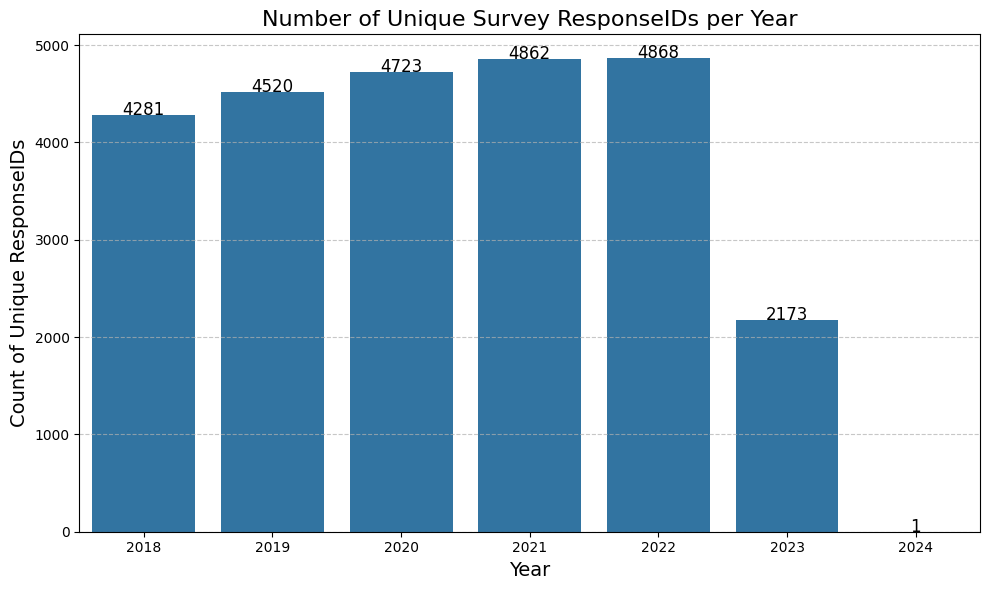

In [4]:
import seaborn as sns

amzn_sales = pd.read_csv("./data/amazon-purchases.csv")

amzn_sales.head()

amzn_sales['Order Date'] = pd.to_datetime(amzn_sales['Order Date'])

# Extract year from the date
amzn_sales['Year'] = amzn_sales['Order Date'].dt.year

# Count unique Survey ResponseIDs per year
yearly_counts = amzn_sales.groupby('Year')['Survey ResponseID'].nunique().reset_index()
yearly_counts.columns = ['Year', 'Unique ResponseIDs']

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Unique ResponseIDs', data=yearly_counts)

# Customize the plot
plt.title('Number of Unique Survey ResponseIDs per Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count of Unique ResponseIDs', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar
for i, count in enumerate(yearly_counts['Unique ResponseIDs']):
    plt.text(i, count + 0.1, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

# Stationarity test Fashion

In [5]:
fashion_df = fashion_df[(fashion_df['Order Date'] >= '2018-01-01')]

# Calculate the total revenue per each day
combined_fashion_df = fashion_df.groupby(["Order Date"]).agg({"Revenue": "sum"}).round(2)

print(combined_fashion_df.head())

            Revenue
Order Date         
2018-01-01   956.84
2018-01-02  1297.17
2018-01-03  1019.96
2018-01-04   956.76
2018-01-05   812.83


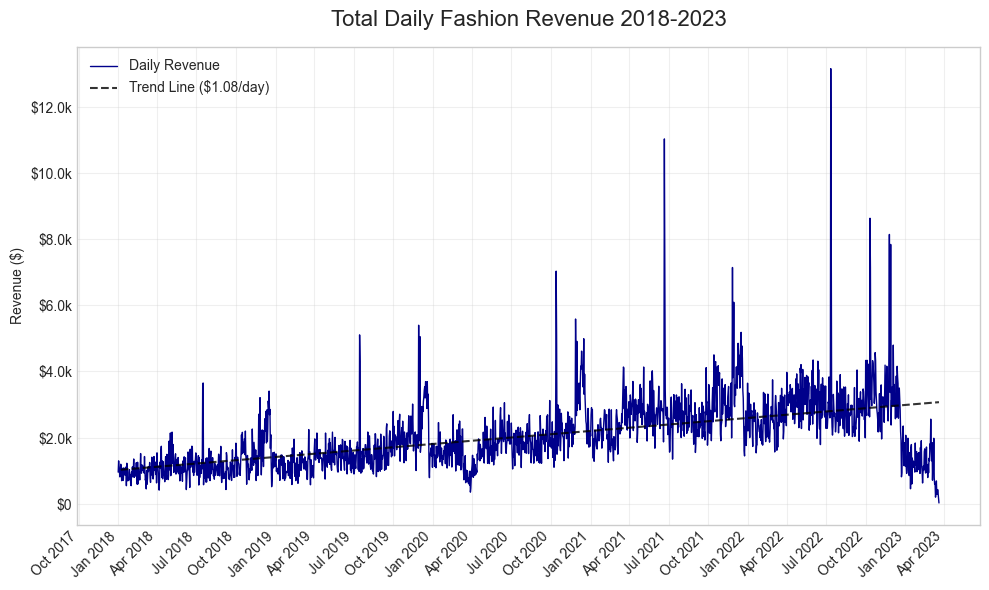

In [ ]:
"""# Make sure the index is datetime
combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with multiple subplots
gig, ax = plt.subplots(figsize=(10, 6)) 

# 1. Line plot with trend line
#ax = axes[0]
ax.plot(combined_fashion_df.index, combined_fashion_df['Revenue'], 
         color='darkblue', alpha=1, linewidth=1, label='Daily Revenue')

# Add trend line
x = np.arange(len(combined_fashion_df))
z = np.polyfit(x, combined_fashion_df['Revenue'], 1)
p = np.poly1d(z)
ax.plot(combined_fashion_df.index[6:], p(np.arange(len(combined_fashion_df)-6)), 
        "k--", linewidth=1.5, alpha=0.8, label=f'Trend Line (${z[0]:.2f}/day)')

# Add labels and title
ax.set_title('Total Daily Fashion Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()"""

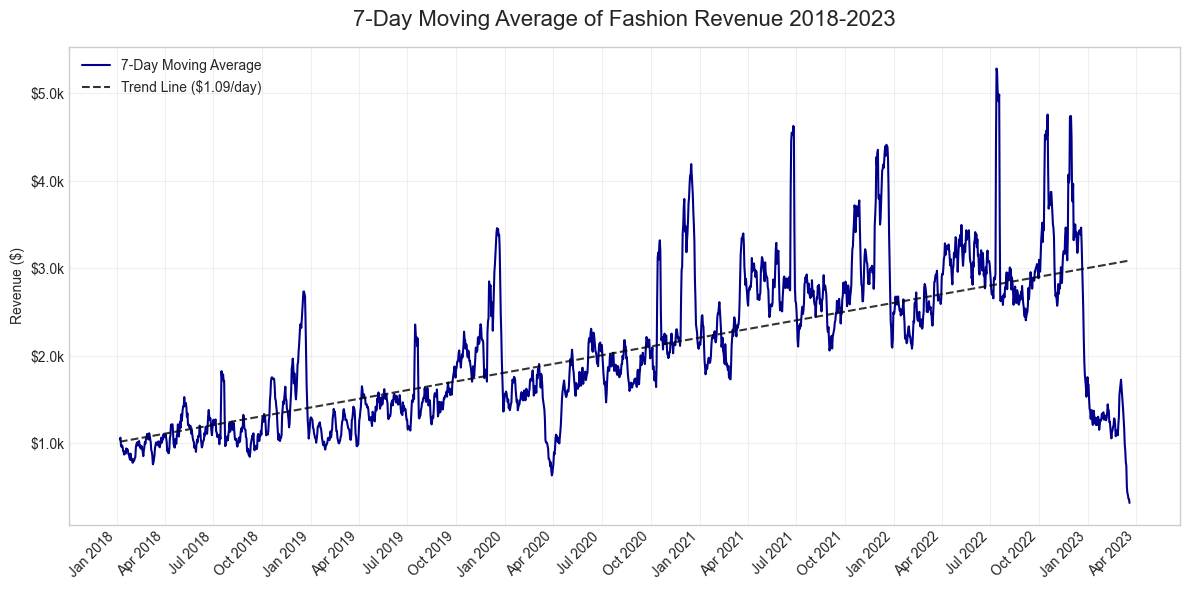

In [ ]:
"""# Make sure the index is datetime
combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

# Calculate the 7-day Simple Moving Average
combined_fashion_df['SMA7'] = combined_fashion_df['Revenue'].rolling(window=7).mean()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot only the 7-day SMA (not the daily revenue)
ax.plot(combined_fashion_df.index, combined_fashion_df['SMA7'], 
        color='darkblue', linewidth=1.5, alpha=1,label='7-Day Moving Average')

# Add trend line for the SMA7 instead of daily revenue
x = np.arange(len(combined_fashion_df))
z = np.polyfit(x[6:], combined_fashion_df['SMA7'].dropna(), 1)  # Start from index 6 to skip NaN values
p = np.poly1d(z)
ax.plot(combined_fashion_df.index[6:], p(np.arange(len(combined_fashion_df)-6)), 
        "k--", linewidth=1.5, alpha=0.8, label=f'Trend Line (${z[0]:.2f}/day)')

# Add labels and title
ax.set_title('7-Day Moving Average of Fashion Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()"""

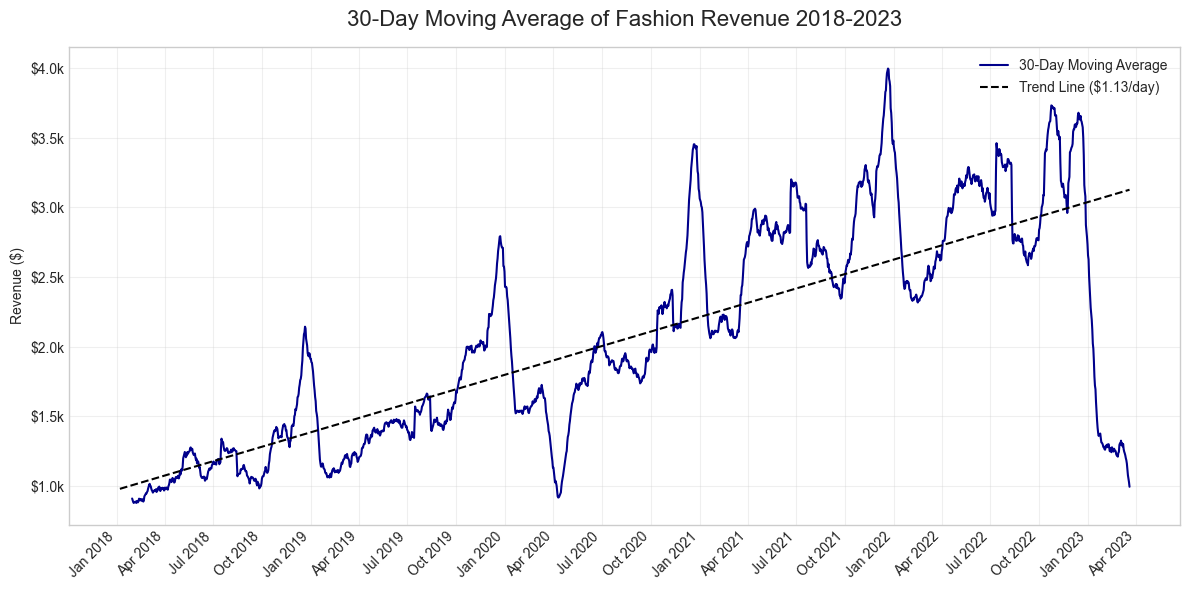

In [ ]:
"""# Make sure the index is datetime
combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

# Calculate the 7-day Simple Moving Average
combined_fashion_df['SMA30'] = combined_fashion_df['Revenue'].rolling(window=30).mean()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot only the 7-day SMA (not the daily revenue)
ax.plot(combined_fashion_df.index, combined_fashion_df['SMA30'], 
        color='darkblue', linewidth=1.5, label='30-Day Moving Average')

# Add trend line for the SMA7 instead of daily revenue
x = np.arange(len(combined_fashion_df))
z = np.polyfit(x[29:], combined_fashion_df['SMA30'].dropna(), 1)  # Start from index 29 to skip NaN values
p = np.poly1d(z)
ax.plot(combined_fashion_df.index[6:], p(np.arange(len(combined_fashion_df)-6)), 
        "k--", linewidth=1.5, alpha=1, label=f'Trend Line (${z[0]:.2f}/day)')

# Add labels and title
ax.set_title('30-Day Moving Average of Fashion Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()"""

## Combined plot 

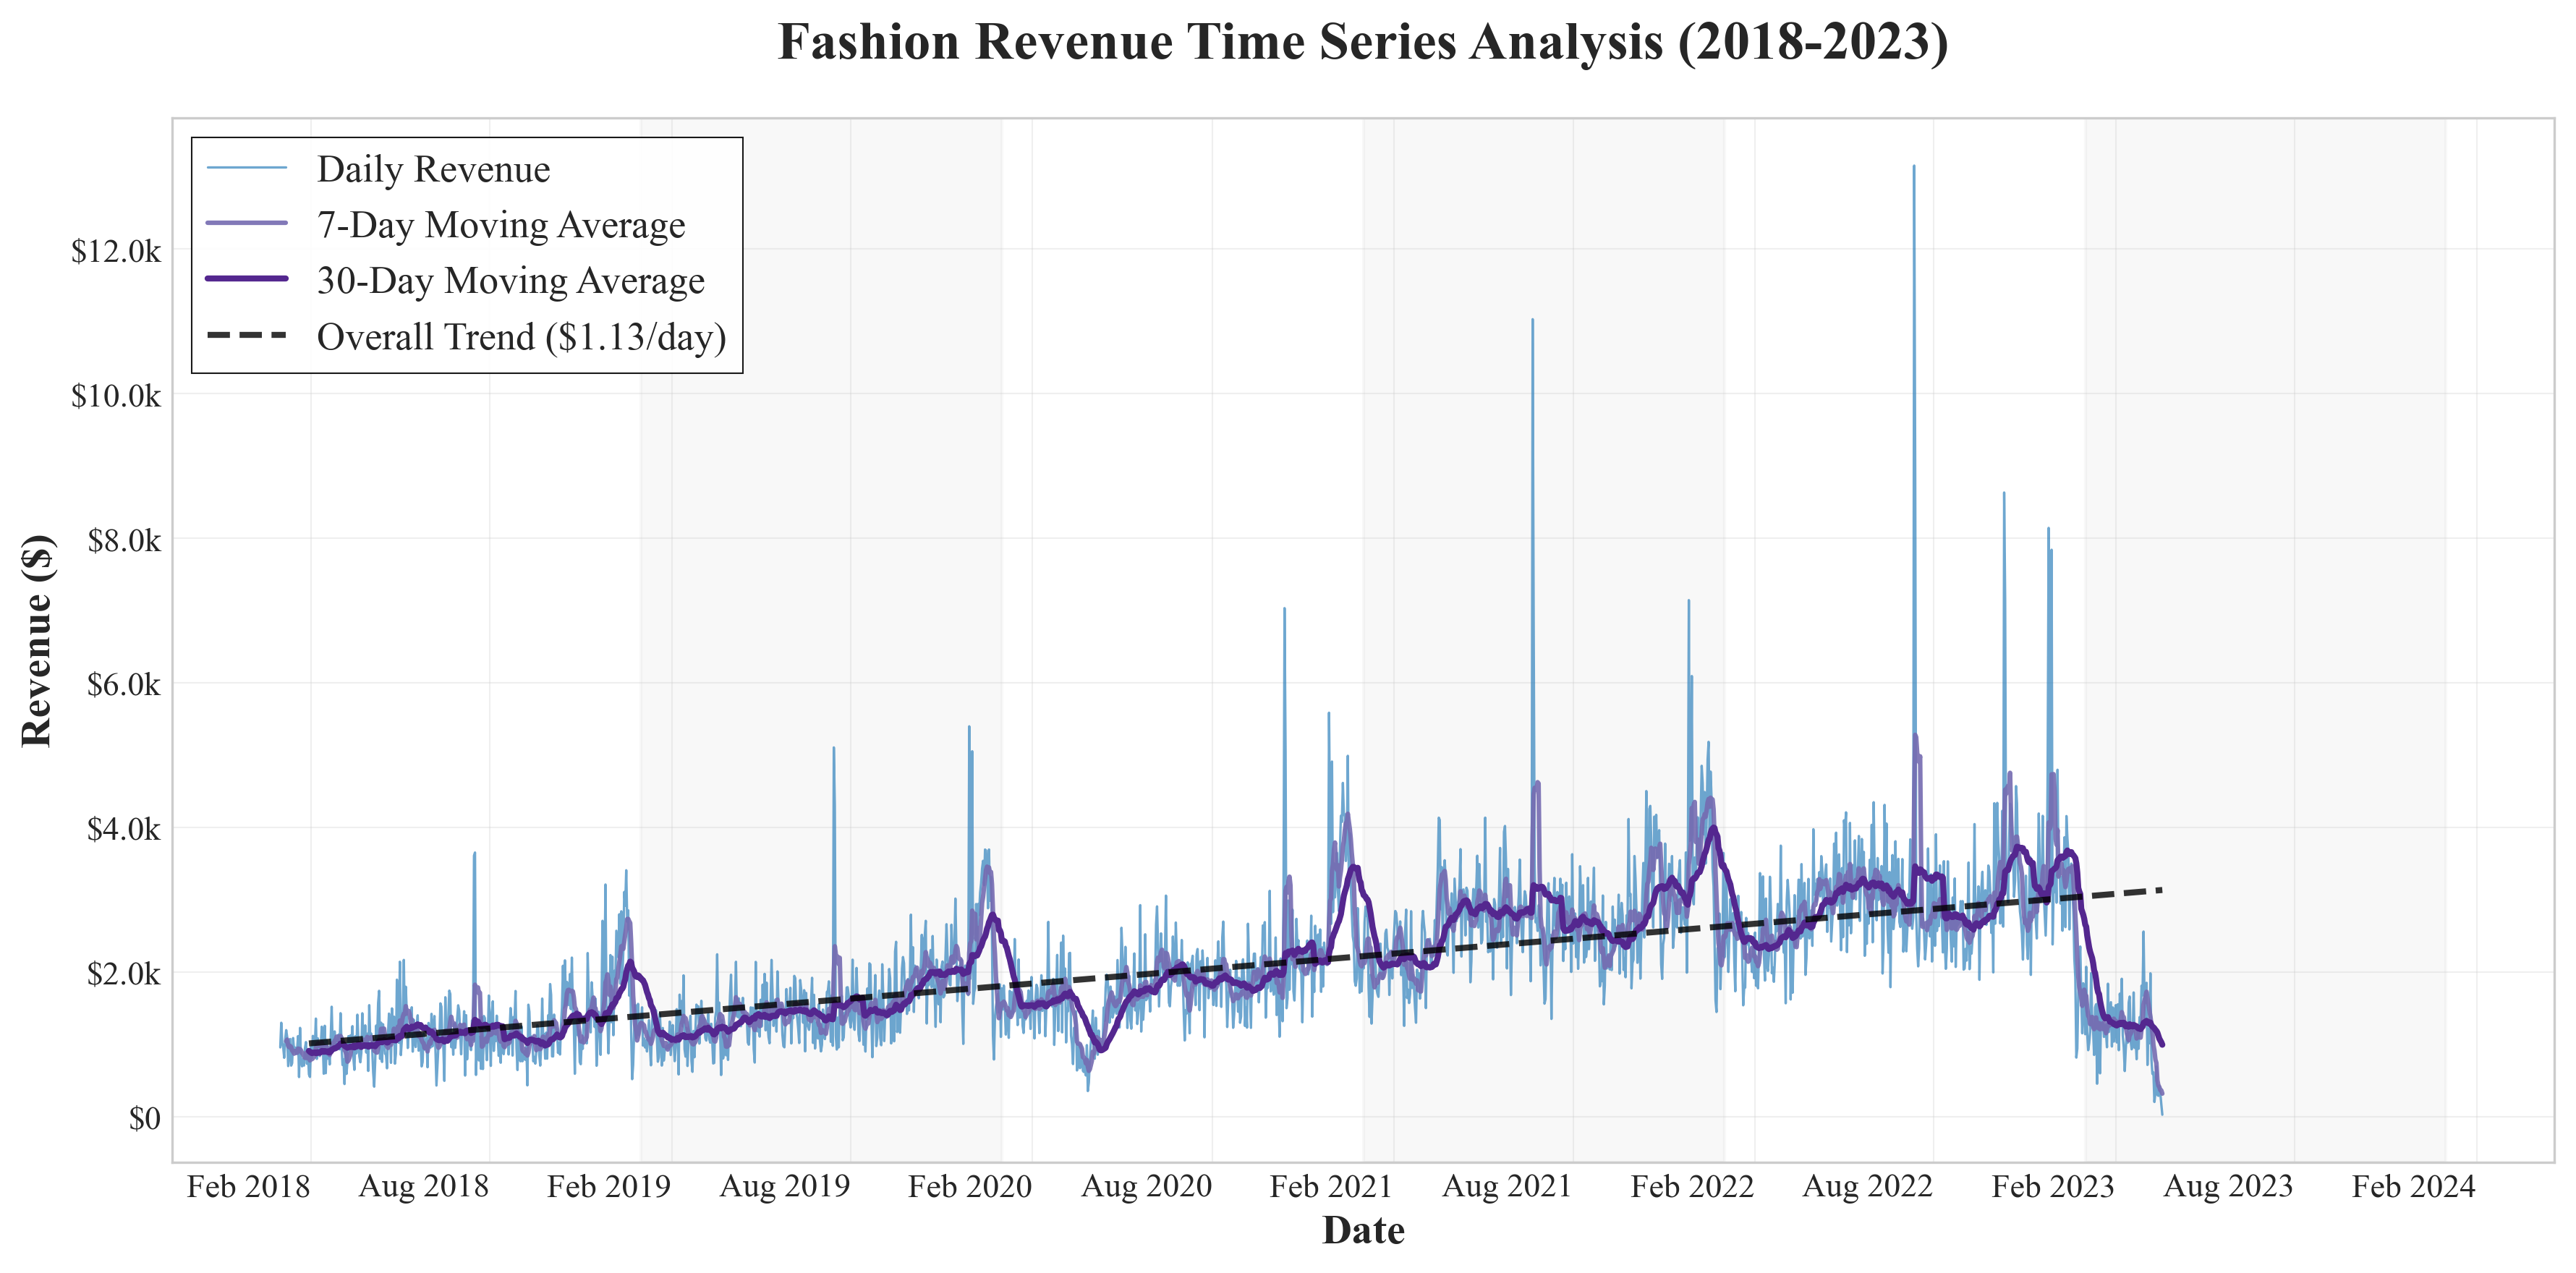


=== Combined Revenue Analysis Summary ===
Analysis Period: 2018-01-01 to 2023-03-20
Total Days: 1,905
Average Daily Revenue: $2,053.93
Daily Revenue Std Dev: $1,047.42
Revenue Growth Trend: $1.13 per day ($413 per year)

Volatility Analysis:
Daily Revenue Volatility: $1,047
7-Day MA Volatility: $868 (17.2% reduction)
30-Day MA Volatility: $795 (24.1% reduction)


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Make sure the index is datetime
combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

# Calculate moving averages
combined_fashion_df['SMA7'] = combined_fashion_df['Revenue'].rolling(window=7).mean()
combined_fashion_df['SMA30'] = combined_fashion_df['Revenue'].rolling(window=30).mean()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set academic style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Create the combined figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot 1: Daily Revenue (with transparency for visual clarity)
ax.plot(combined_fashion_df.index, combined_fashion_df['Revenue'],
        color='#3182bd', alpha=0.7, linewidth=0.8, 
        label='Daily Revenue', zorder=1)

# Plot 2: 7-Day Moving Average
ax.plot(combined_fashion_df.index, combined_fashion_df['SMA7'],
        color='#756bb1', linewidth=1.5, alpha=0.9,
        label='7-Day Moving Average', zorder=2)

# Plot 3: 30-Day Moving Average
ax.plot(combined_fashion_df.index, combined_fashion_df['SMA30'],
        color='#54278f', linewidth=2.0, alpha=1.0,
        label='30-Day Moving Average', zorder=3)

# Add trend line based on 30-day moving average
x = np.arange(len(combined_fashion_df))
# Use 30-day MA for trend calculation (more stable)
valid_data = combined_fashion_df['SMA30'].dropna()
valid_indices = x[29:]  # Start from index 29 to skip NaN values

z = np.polyfit(valid_indices, valid_data, 1)
p = np.poly1d(z)

# Plot trend line
ax.plot(combined_fashion_df.index[29:], p(valid_indices),
        "k--", linewidth=2, alpha=0.8, 
        label=f'Overall Trend (${z[0]:.2f}/day)', zorder=4)

# Formatting
ax.set_title('Fashion Revenue Time Series Analysis (2018-2023)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=14, fontweight='bold')

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

# Grid styling
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Legend
legend = ax.legend(loc='upper left', fontsize=13, frameon=True, 
                  fancybox=False, shadow=False, framealpha=0.9,
                  edgecolor='black')

# Set legend frame linewidth separately
legend.get_frame().set_linewidth(0.5)

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))  # Minor ticks every 3 months

# Rotate x-axis labels
plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

# Add subtle background shading for different years (optional)
years = pd.date_range(start=combined_fashion_df.index.min(), 
                     end=combined_fashion_df.index.max(), freq='YS')
for i, year in enumerate(years[1:]):  # Skip first year
    if i % 2 == 0:  # Alternate shading
        ax.axvspan(year, year + pd.DateOffset(years=1), 
                  alpha=0.05, color='gray', zorder=0)

# Adjust layout
plt.tight_layout()


# Save the plot
plt.savefig('./Exports/combined_fashion_revenue_analysis.png', 
           dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# Print summary information
print("\n=== Combined Revenue Analysis Summary ===")
print(f"Analysis Period: {combined_fashion_df.index.min().strftime('%Y-%m-%d')} to {combined_fashion_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(combined_fashion_df):,}")
print(f"Average Daily Revenue: ${combined_fashion_df['Revenue'].mean():,.2f}")
print(f"Daily Revenue Std Dev: ${combined_fashion_df['Revenue'].std():,.2f}")
print(f"Revenue Growth Trend: ${z[0]:.2f} per day (${z[0]*365:.0f} per year)")

# Calculate volatility reduction from smoothing
daily_volatility = combined_fashion_df['Revenue'].std()
sma7_volatility = combined_fashion_df['SMA7'].std()
sma30_volatility = combined_fashion_df['SMA30'].std()

print(f"\nVolatility Analysis:")
print(f"Daily Revenue Volatility: ${daily_volatility:,.0f}")
print(f"7-Day MA Volatility: ${sma7_volatility:,.0f} ({(1-sma7_volatility/daily_volatility)*100:.1f}% reduction)")
print(f"30-Day MA Volatility: ${sma30_volatility:,.0f} ({(1-sma30_volatility/daily_volatility)*100:.1f}% reduction)")

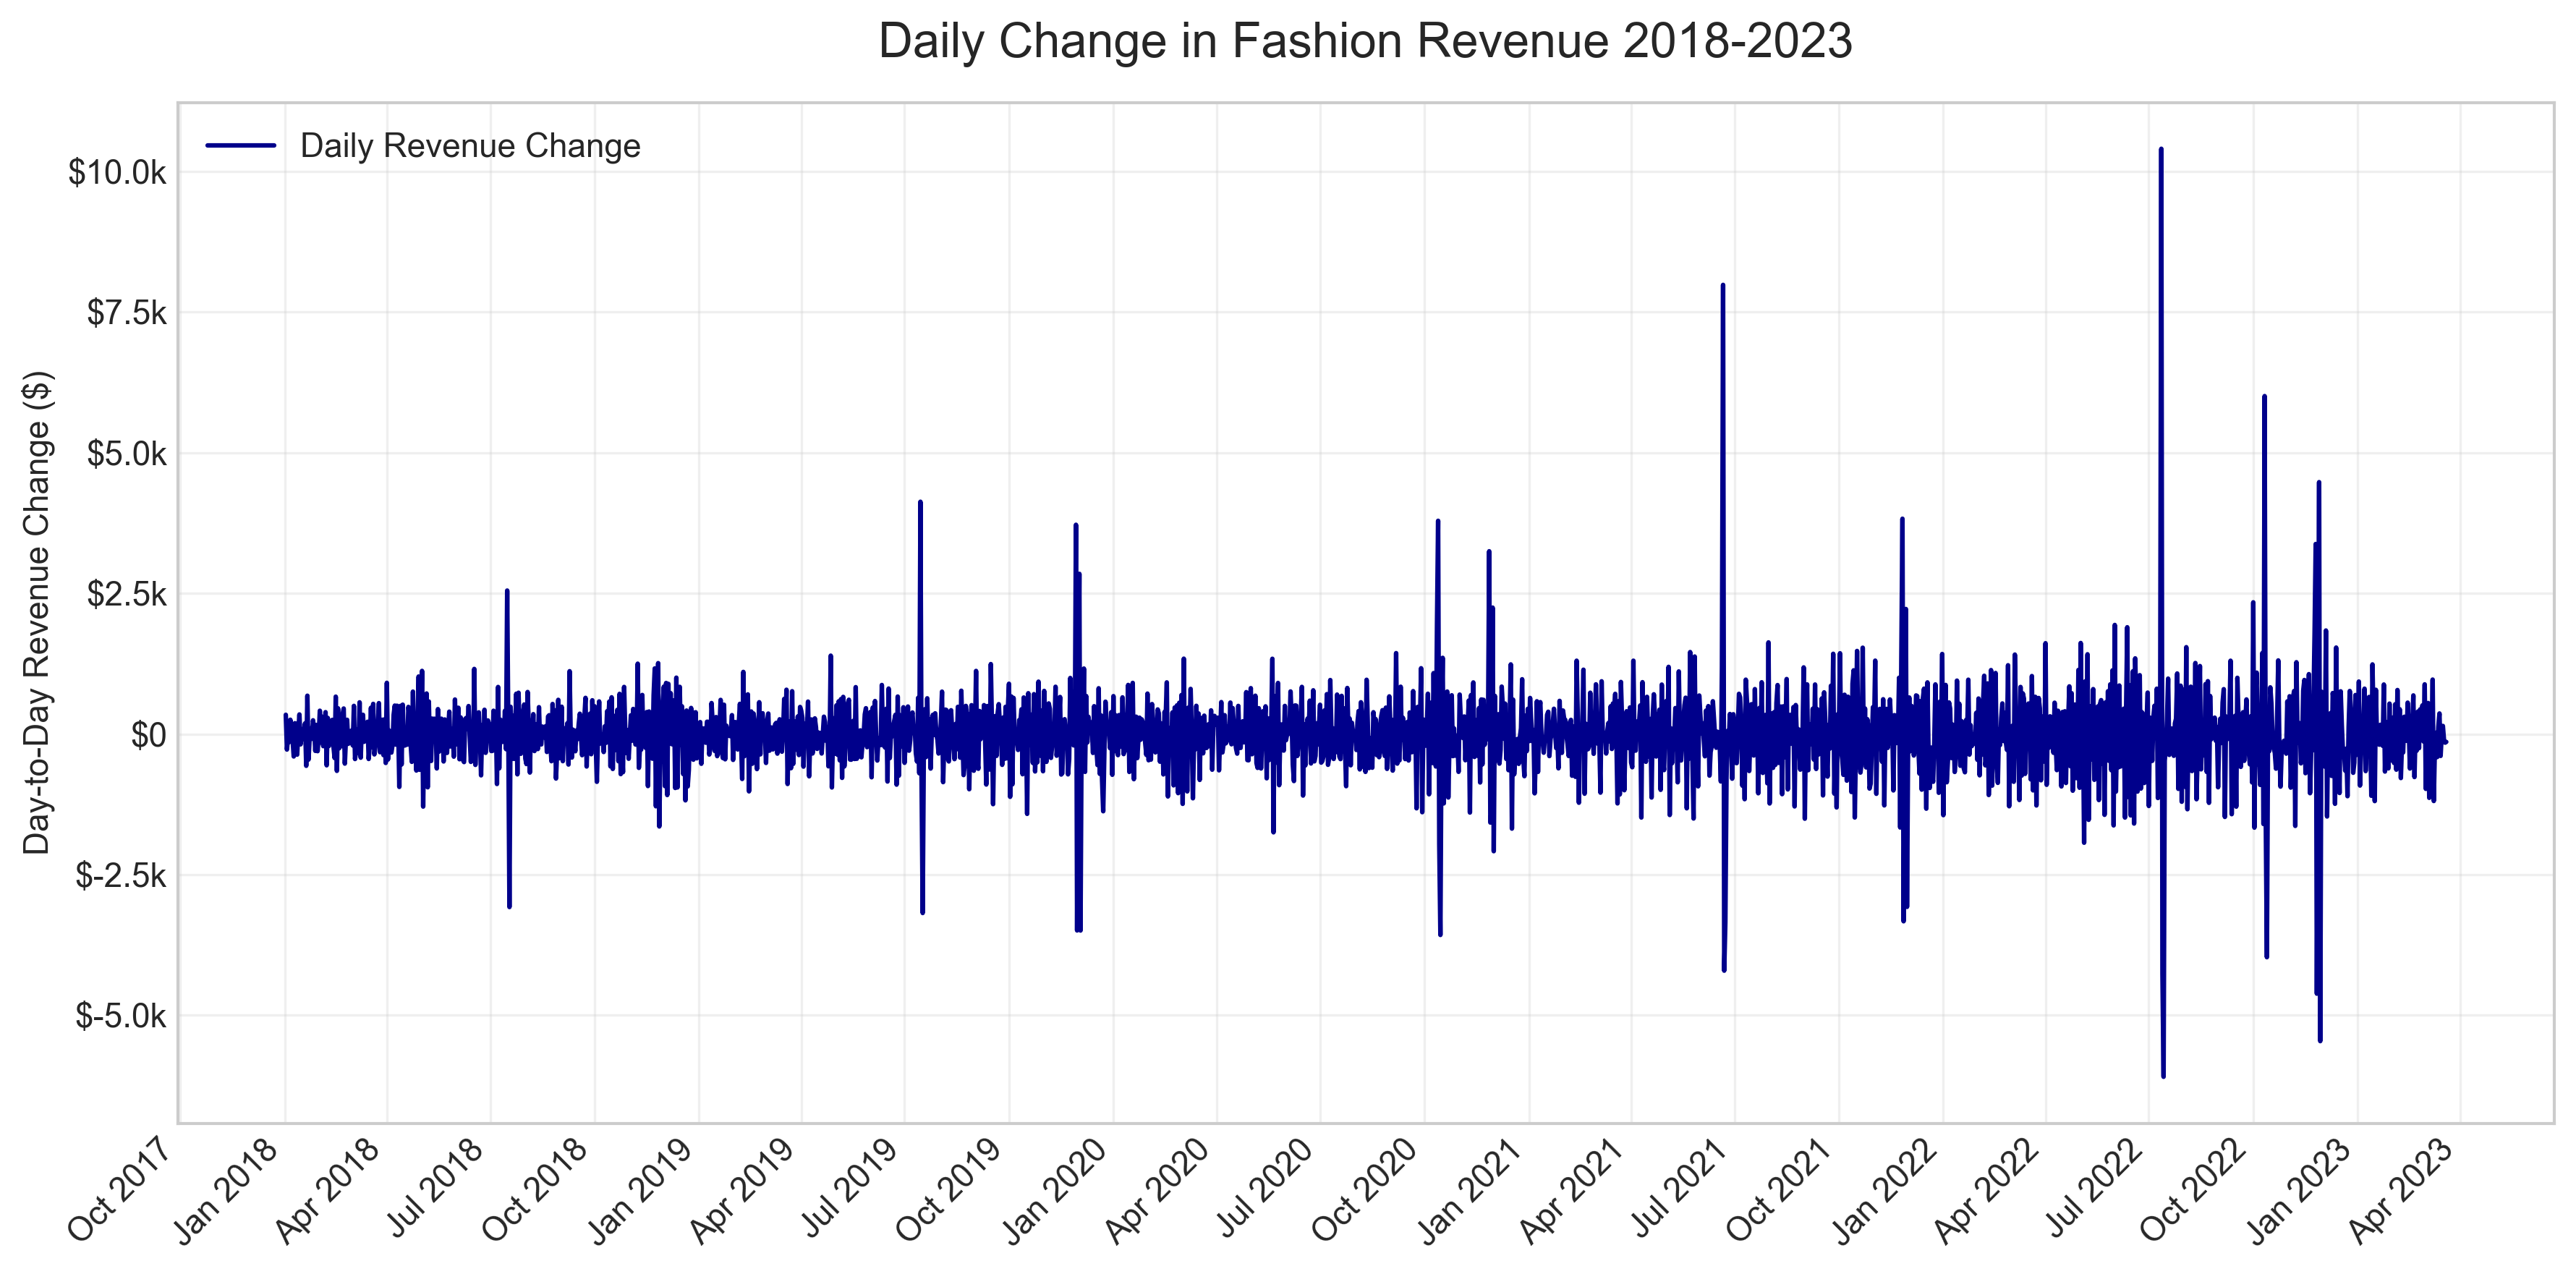

In [10]:
# Make sure the index is datetime
combined_fashion_df.index = pd.to_datetime(combined_fashion_df.index)

# Calculate the first-order difference of revenue
combined_fashion_df['Revenue_Diff'] = combined_fashion_df['Revenue'].diff()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if abs(x) >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot the first-order difference
ax.plot(combined_fashion_df.index[1:], combined_fashion_df['Revenue_Diff'].iloc[1:], 
        color='darkblue', alpha=1, linewidth=1.5, label='Daily Revenue Change')


# Add labels and title
ax.set_title('Daily Change in Fashion Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Day-to-Day Revenue Change ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) test

In [11]:
ADF_df = combined_fashion_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [12]:
### Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

### SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value First order difference: {adf_result[1]}')

p-value Revenue: 0.009760838786308871
p-value SMA7: 0.043099306720730576
p-value SMA30: 0.20128268155517337
p-value First order difference: 1.0055800944183514e-25


# Stationarity tests Grocieries

In [13]:
grocery_df = grocery_df[(grocery_df['Order Date'] >= '2018-01-01')]

# Calculate the total revenue per each day
combined_grocery_df = grocery_df.groupby(["Order Date"]).agg({"Revenue": "sum"}).round(2)

combined_grocery_df.head()

,Revenue
Order Date,
2018-01-01,409.89
2018-01-02,670.35
2018-01-03,472.03
2018-01-04,358.15
2018-01-05,441.39


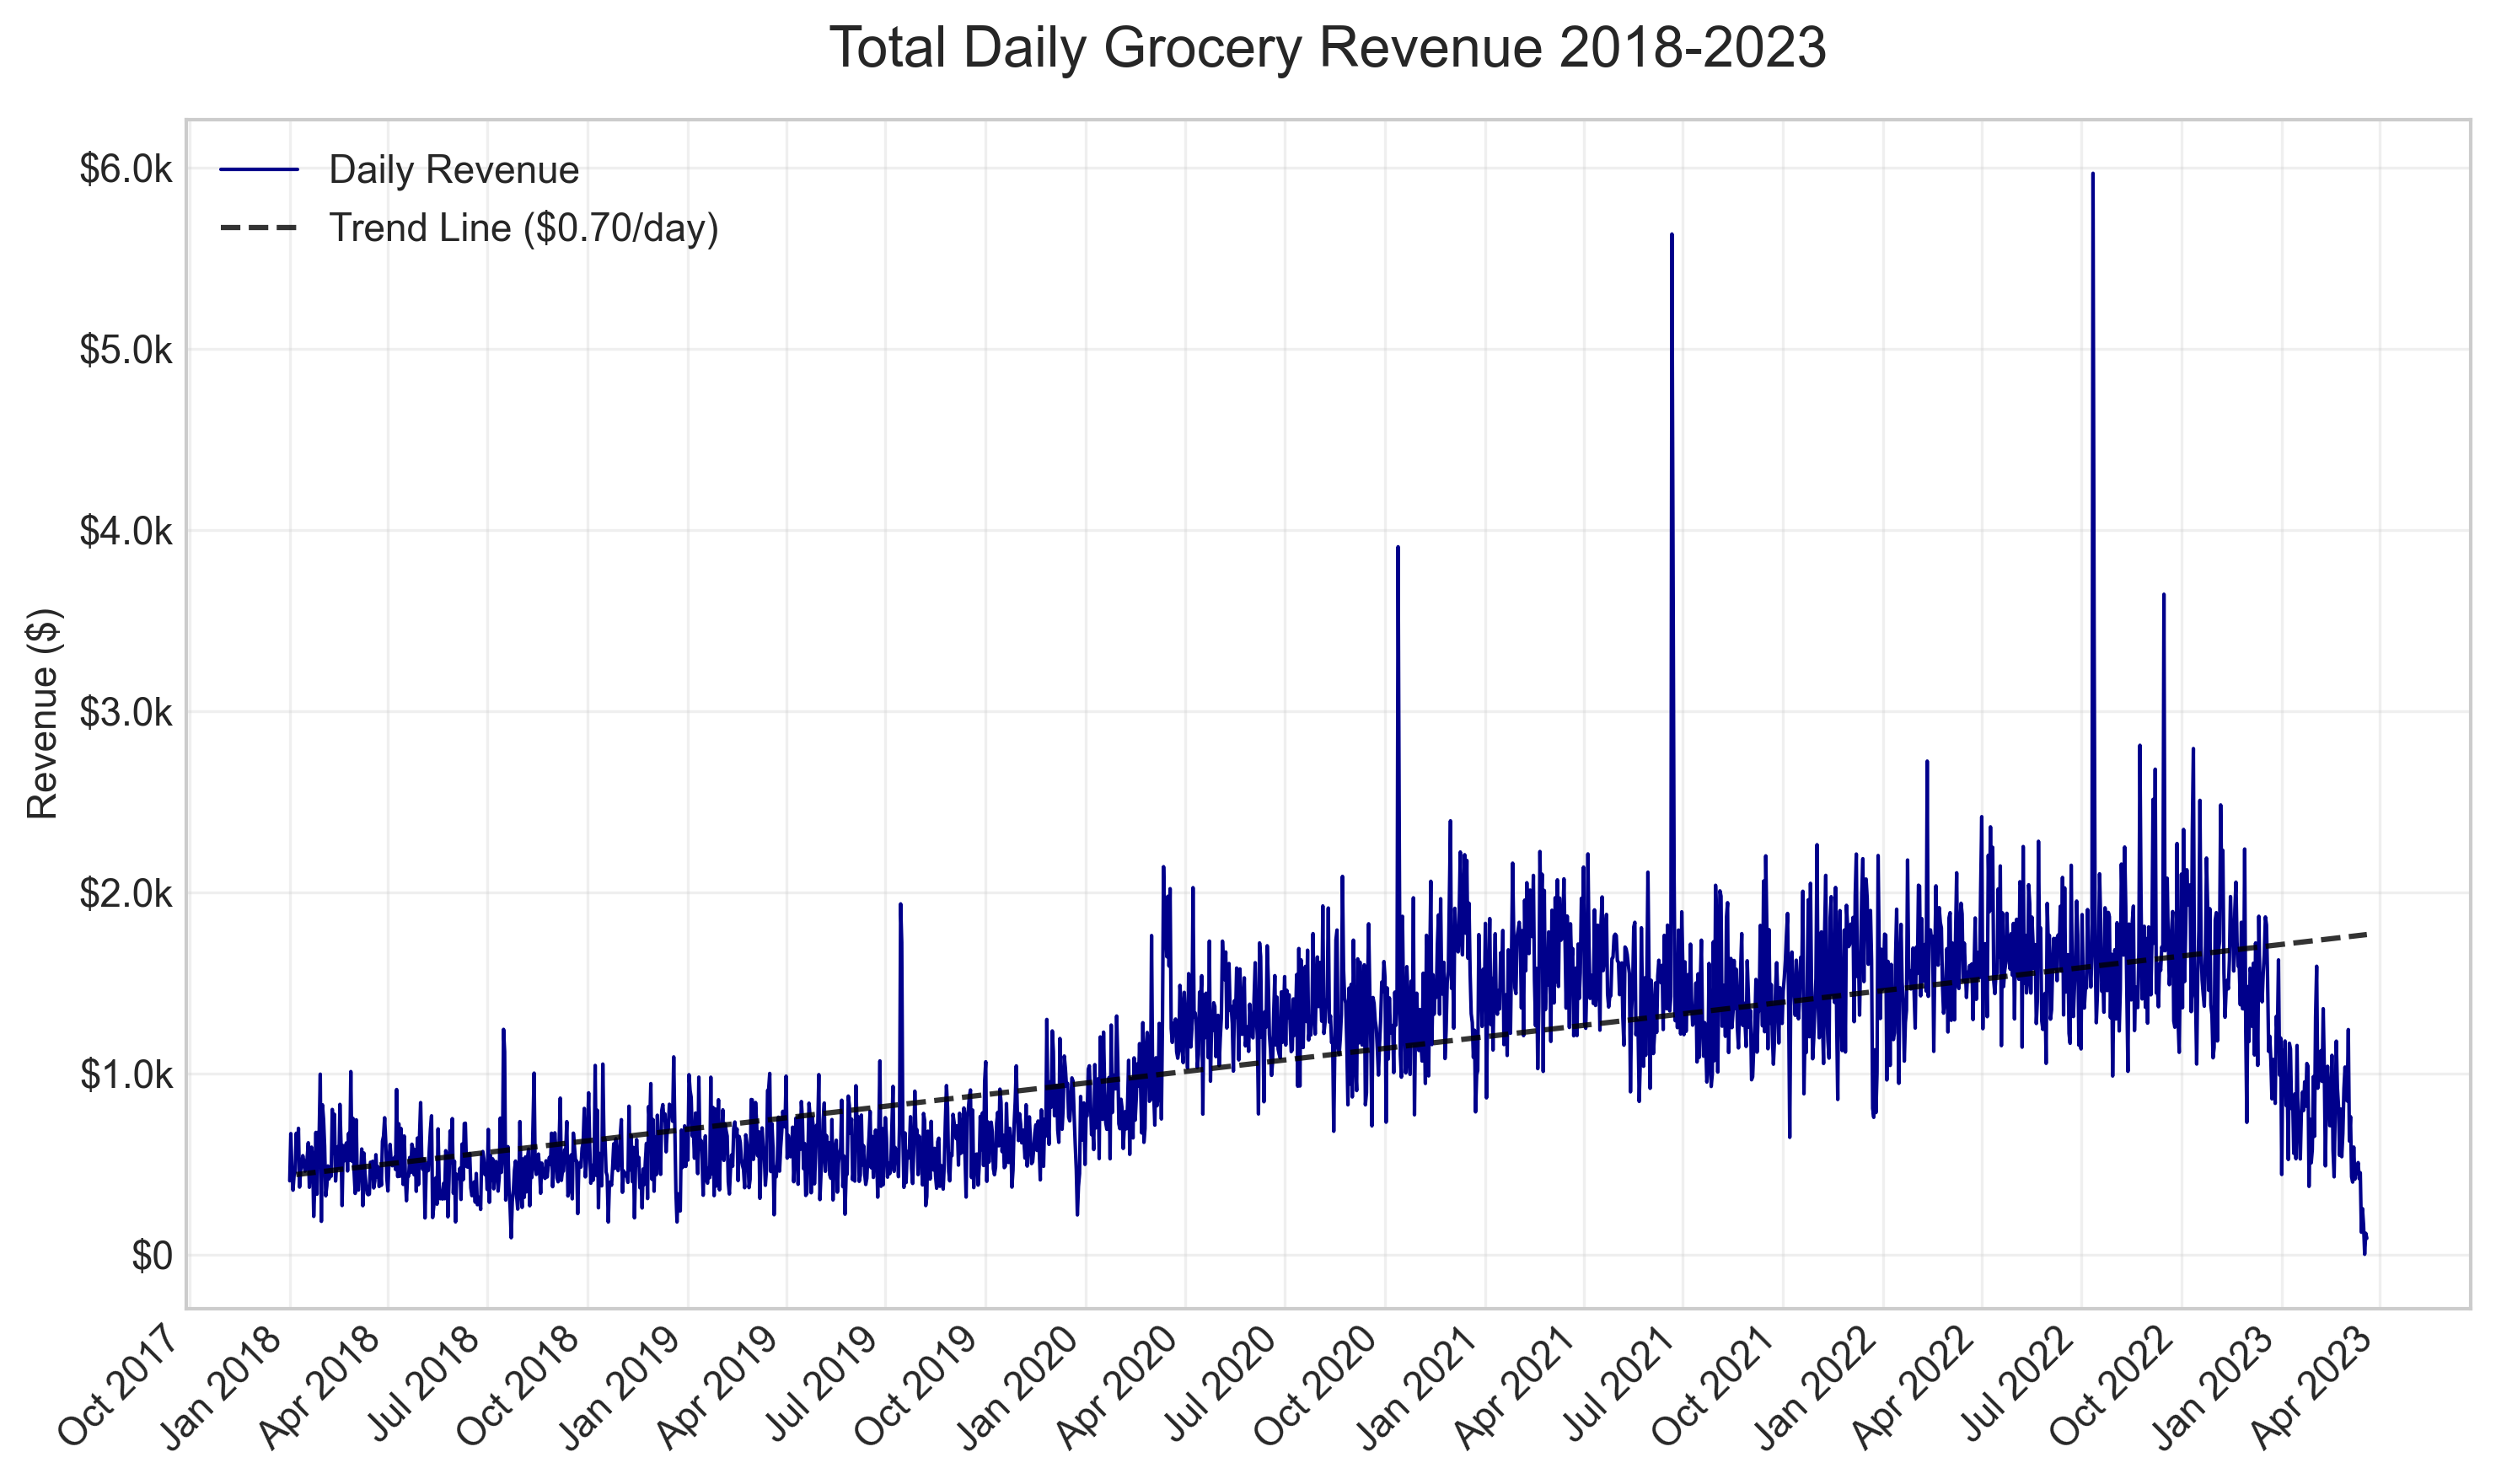

In [ ]:
"""

# Make sure the index is datetime
combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with multiple subplots
gig, ax = plt.subplots(figsize=(10, 6)) 

# 1. Line plot with trend line
#ax = axes[0]
ax.plot(combined_grocery_df.index, combined_grocery_df['Revenue'], 
         color='darkblue', alpha=1, linewidth=1, label='Daily Revenue')

# Add trend line
x = np.arange(len(combined_grocery_df))
z = np.polyfit(x, combined_grocery_df['Revenue'], 1)
p = np.poly1d(z)
ax.plot(combined_grocery_df.index[6:], p(np.arange(len(combined_grocery_df)-6)), 
        "k--", linewidth=1.5, alpha=0.8, label=f'Trend Line (${z[0]:.2f}/day)')

# Add labels and title
ax.set_title('Total Daily Grocery Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()"""

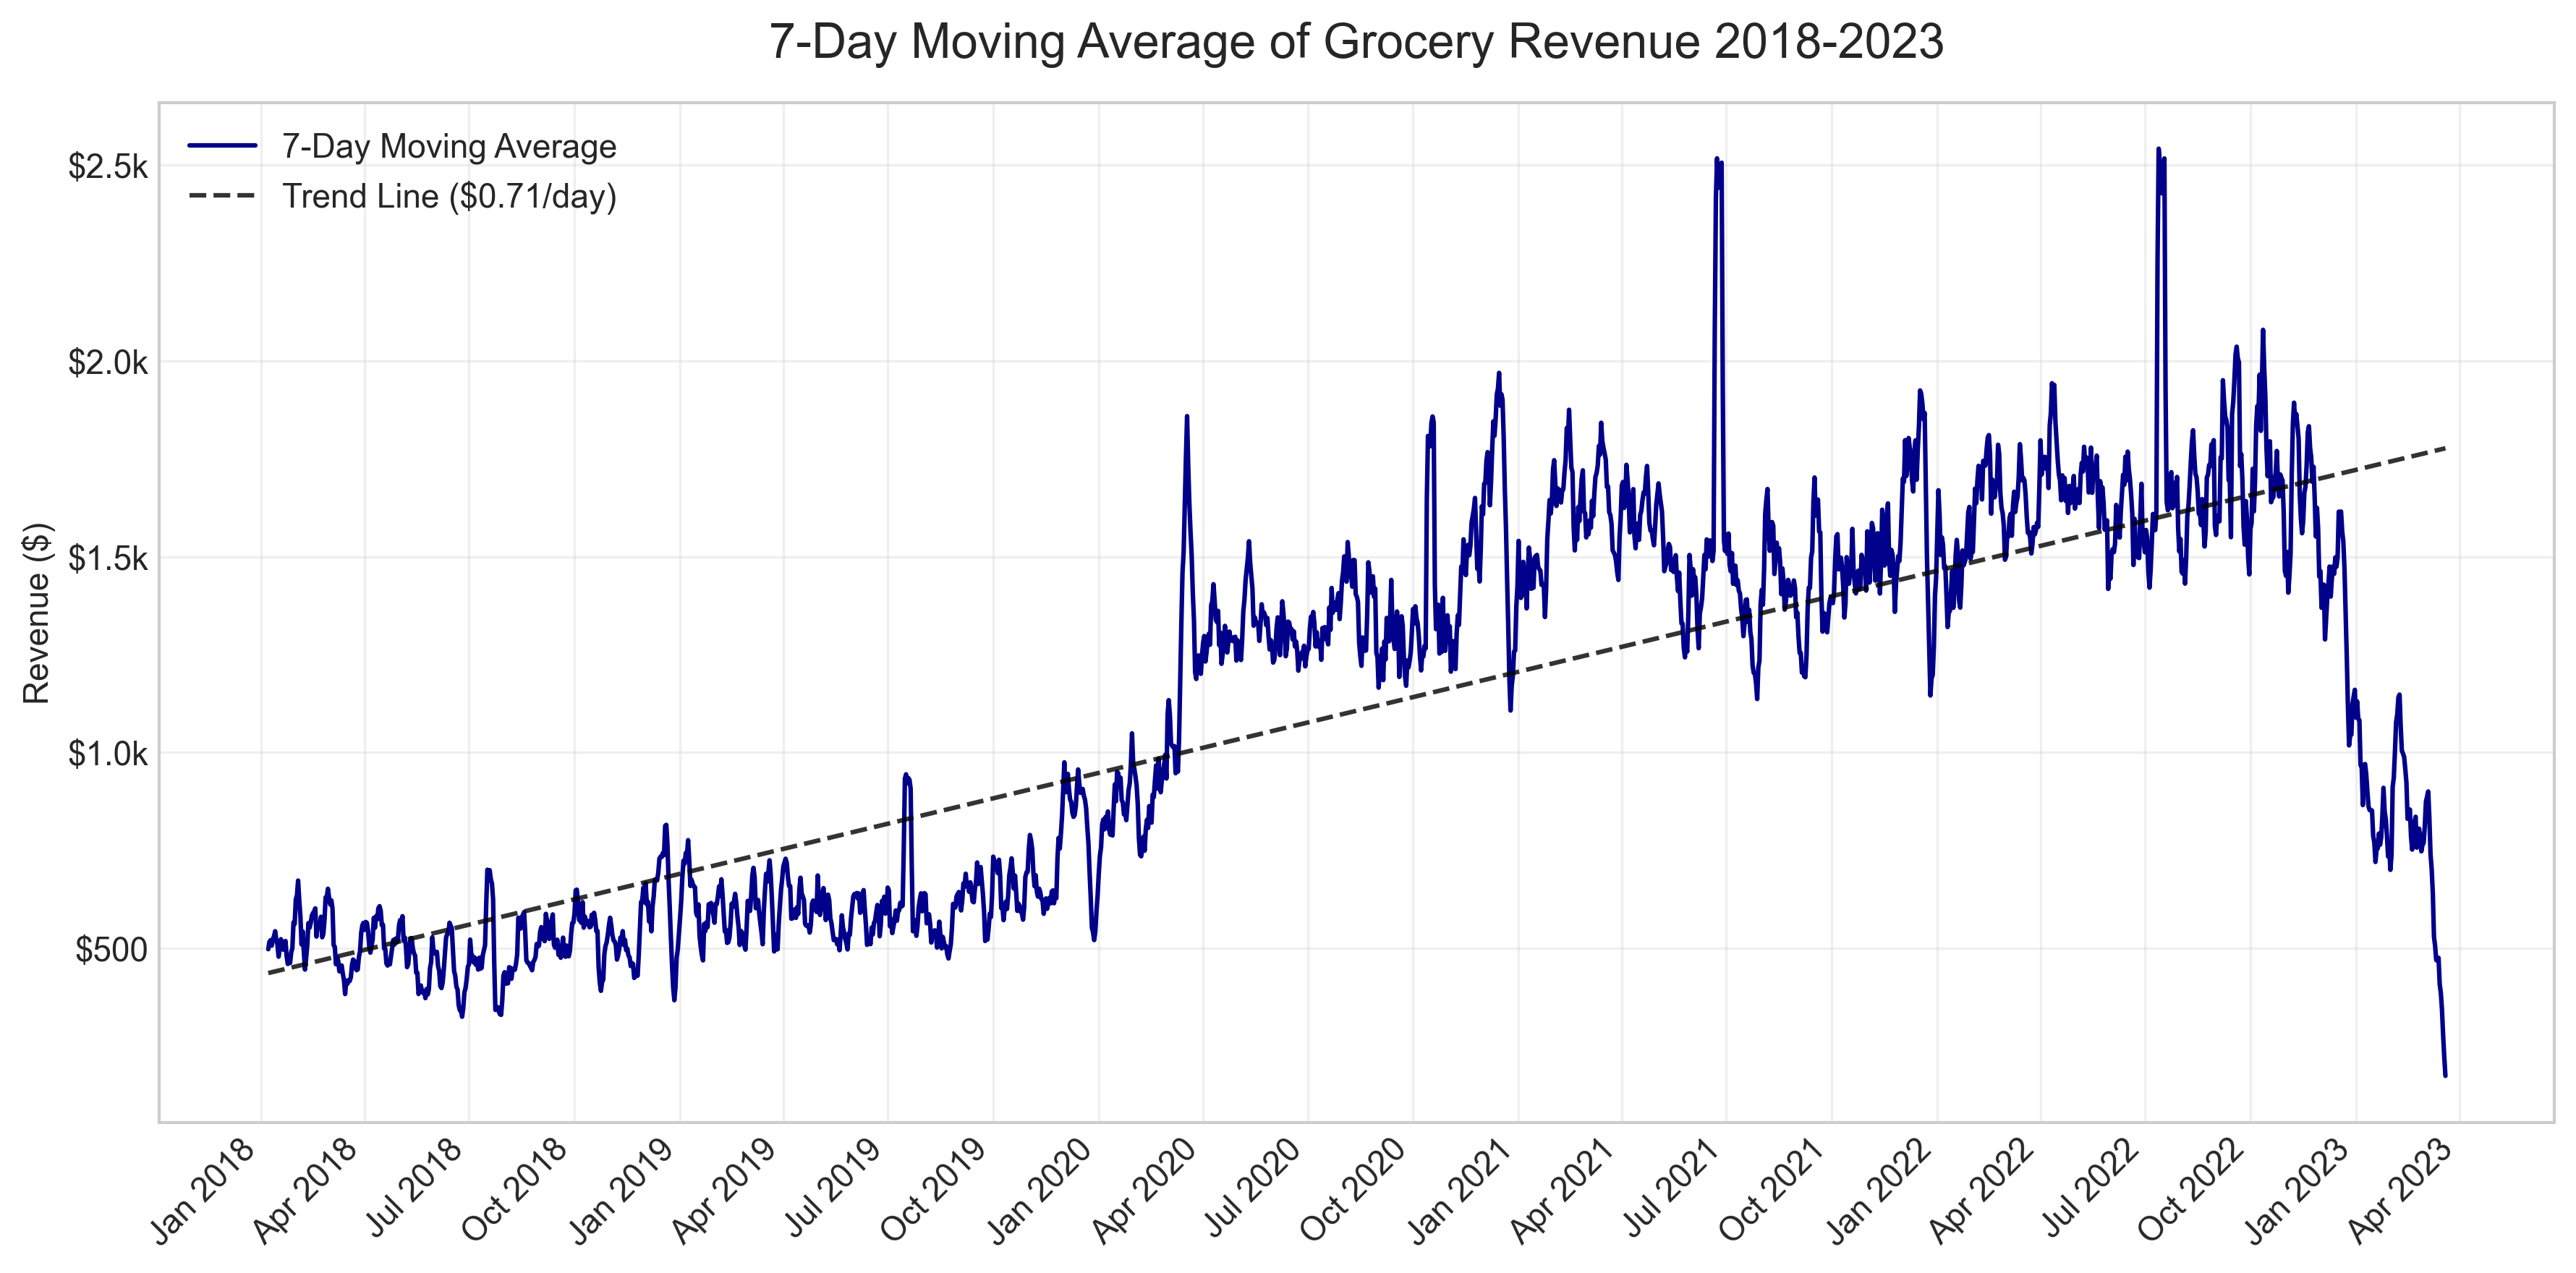

In [ ]:
"""# Make sure the index is datetime
combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Calculate the 7-day Simple Moving Average
combined_grocery_df['SMA7'] = combined_grocery_df['Revenue'].rolling(window=7).mean()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot only the 7-day SMA (not the daily revenue)
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA7'], 
        color='darkblue', linewidth=1.5, alpha=1,label='7-Day Moving Average')

# Add trend line for the SMA7 instead of daily revenue
x = np.arange(len(combined_grocery_df))
z = np.polyfit(x[6:], combined_grocery_df['SMA7'].dropna(), 1)  # Start from index 6 to skip NaN values
p = np.poly1d(z)
ax.plot(combined_grocery_df.index[6:], p(np.arange(len(combined_grocery_df)-6)), 
        "k--", linewidth=1.5, alpha=0.8, label=f'Trend Line (${z[0]:.2f}/day)')

# Add labels and title
ax.set_title('7-Day Moving Average of Grocery Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()"""

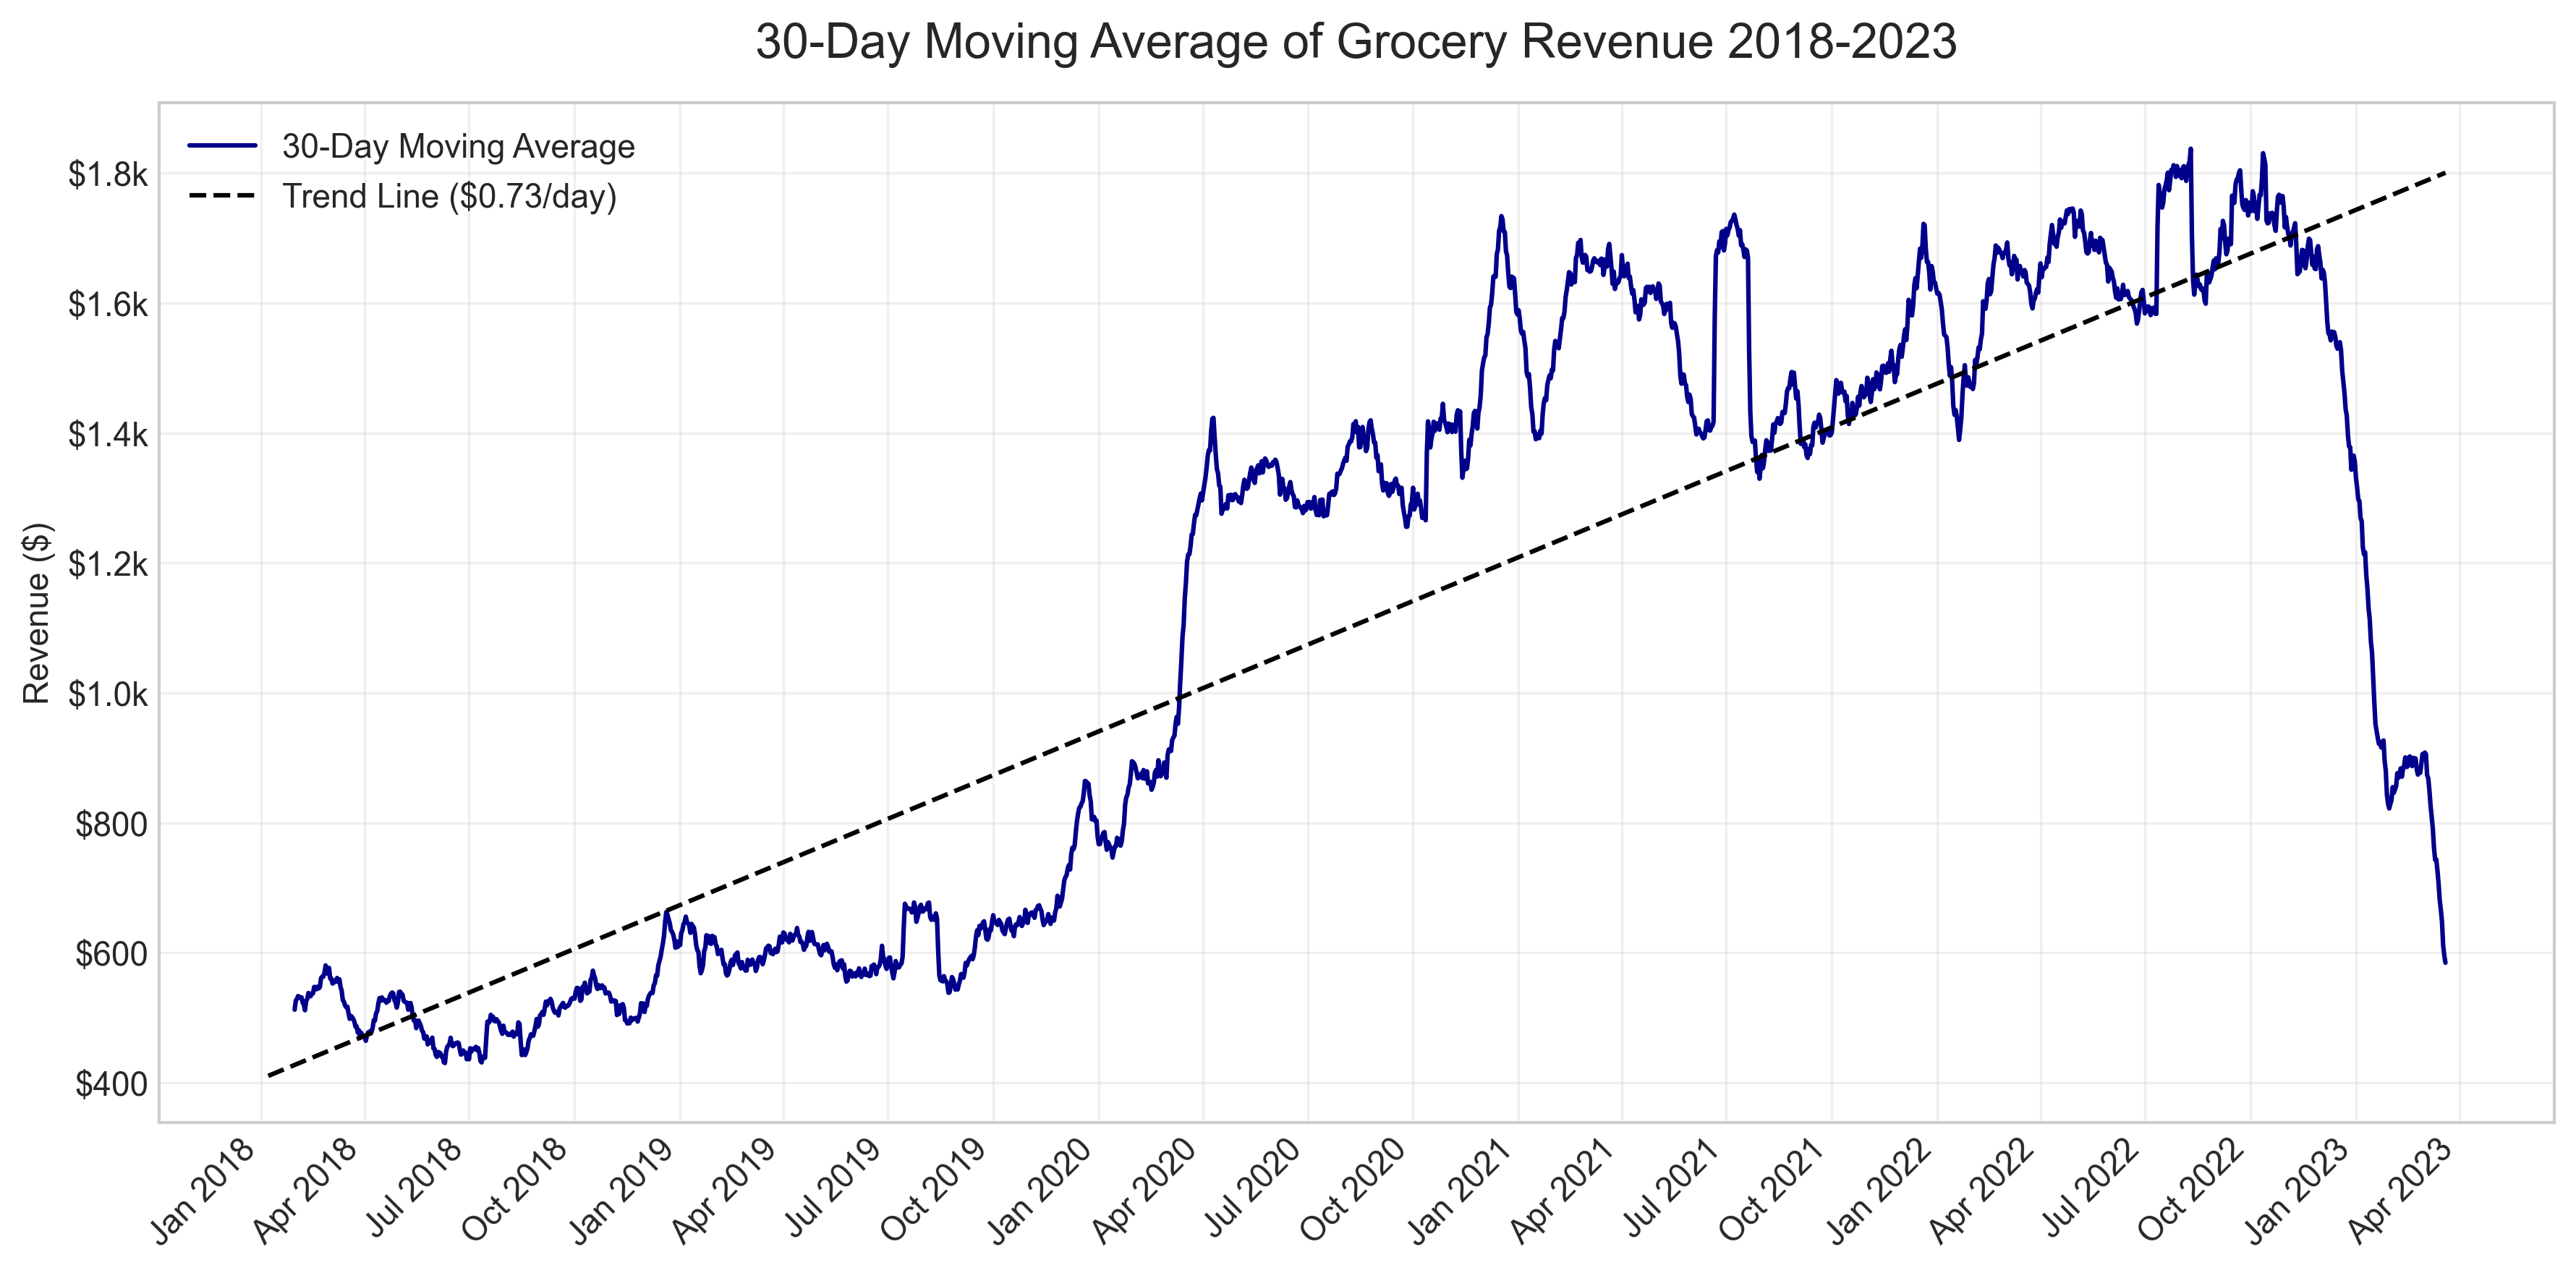

In [ ]:
"""# Make sure the index is datetime
combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Calculate the 7-day Simple Moving Average
combined_grocery_df['SMA30'] = combined_grocery_df['Revenue'].rolling(window=30).mean()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot only the 7-day SMA (not the daily revenue)
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA30'], 
        color='darkblue', linewidth=1.5, label='30-Day Moving Average')

# Add trend line for the SMA7 instead of daily revenue
x = np.arange(len(combined_grocery_df))
z = np.polyfit(x[29:], combined_grocery_df['SMA30'].dropna(), 1)  # Start from index 29 to skip NaN values
p = np.poly1d(z)
ax.plot(combined_grocery_df.index[6:], p(np.arange(len(combined_grocery_df)-6)), 
        "k--", linewidth=1.5, alpha=1, label=f'Trend Line (${z[0]:.2f}/day)')

# Add labels and title
ax.set_title('30-Day Moving Average of Grocery Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()"""

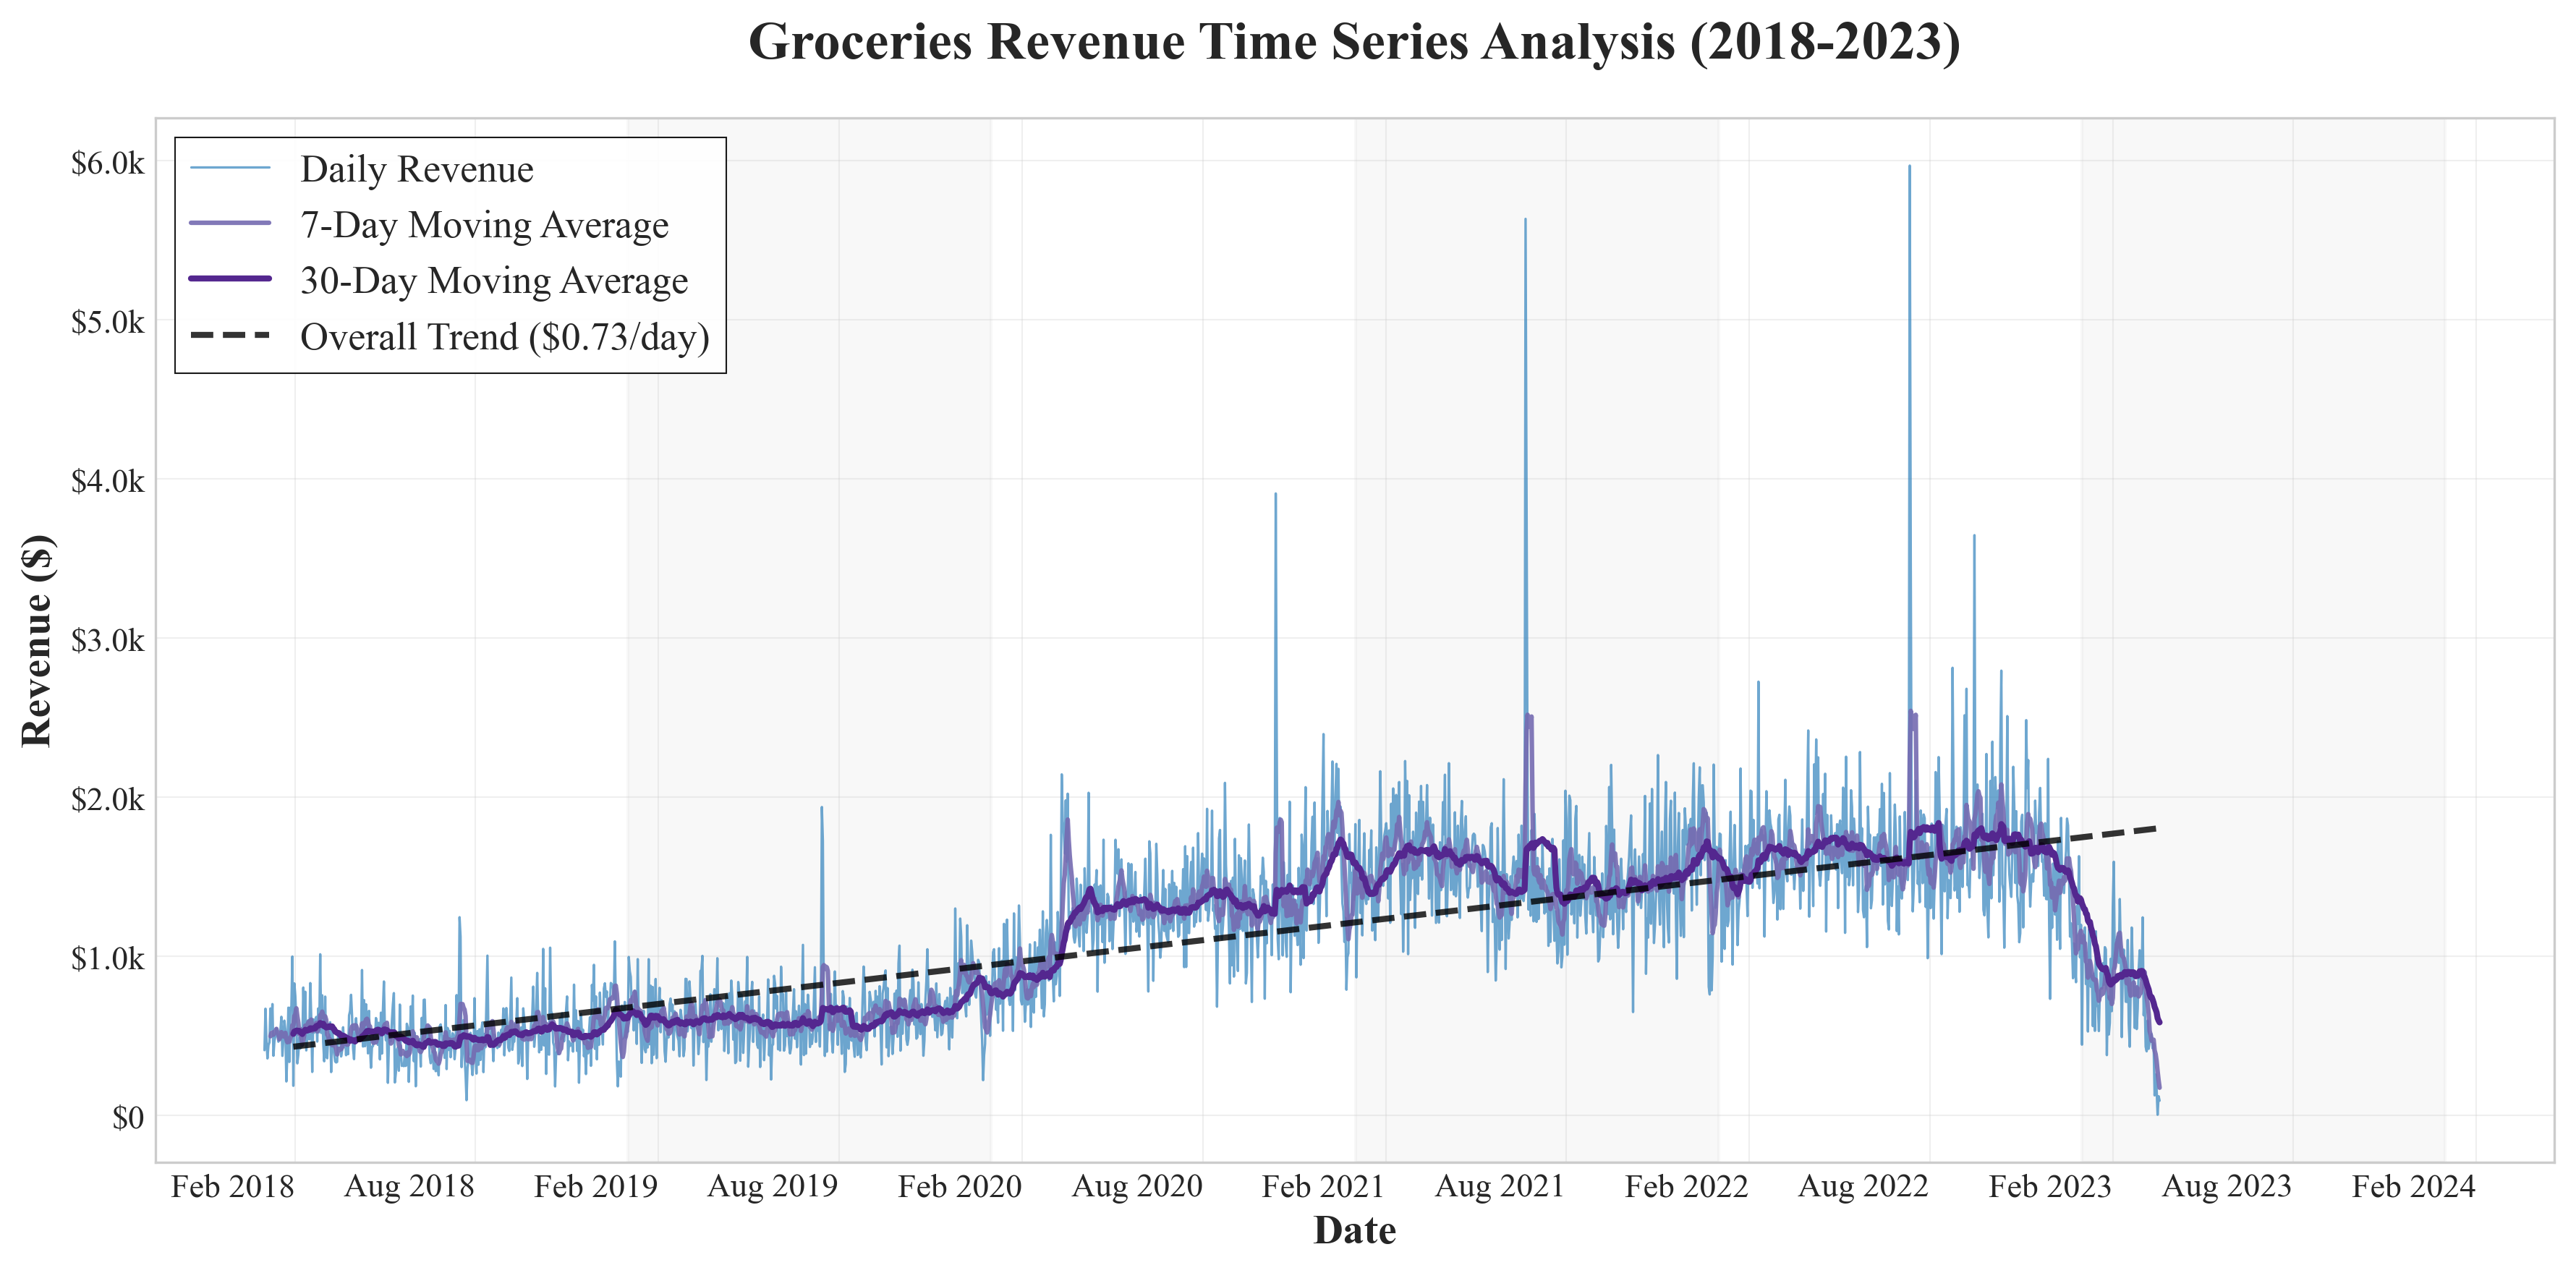


=== Combined Revenue Analysis Summary ===
Analysis Period: 2018-01-01 to 2023-03-20
Total Days: 1,905
Average Daily Revenue: $1,108.55
Daily Revenue Std Dev: $567.13
Revenue Growth Trend: $0.73 per day ($267 per year)

Volatility Analysis:
Daily Revenue Volatility: $567
7-Day MA Volatility: $493 (13.1% reduction)
30-Day MA Volatility: $474 (16.5% reduction)


In [26]:

# Make sure the index is datetime
combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Calculate moving averages
combined_grocery_df['SMA7'] = combined_grocery_df['Revenue'].rolling(window=7).mean()
combined_grocery_df['SMA30'] = combined_grocery_df['Revenue'].rolling(window=30).mean()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set academic style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Liberation Serif', 'DejaVu Serif'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'figure.dpi': 300
})

# Create the combined figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot 1: Daily Revenue (with transparency for visual clarity)
ax.plot(combined_grocery_df.index, combined_grocery_df['Revenue'],
        color='#3182bd', alpha=0.7, linewidth=0.8, 
        label='Daily Revenue', zorder=1)

# Plot 2: 7-Day Moving Average
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA7'],
        color='#756bb1', linewidth=1.5, alpha=0.9,
        label='7-Day Moving Average', zorder=2)

# Plot 3: 30-Day Moving Average
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA30'],
        color='#54278f', linewidth=2.0, alpha=1.0,
        label='30-Day Moving Average', zorder=3)

# Add trend line based on 30-day moving average
x = np.arange(len(combined_grocery_df))
# Use 30-day MA for trend calculation (more stable)
valid_data = combined_grocery_df['SMA30'].dropna()
valid_indices = x[29:]  # Start from index 29 to skip NaN values

z = np.polyfit(valid_indices, valid_data, 1)
p = np.poly1d(z)

# Plot trend line
ax.plot(combined_grocery_df.index[29:], p(valid_indices),
        "k--", linewidth=2, alpha=0.8, 
        label=f'Overall Trend (${z[0]:.2f}/day)', zorder=4)

# Formatting
ax.set_title('Groceries Revenue Time Series Analysis (2018-2023)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue ($)', fontsize=14, fontweight='bold')

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

# Grid styling
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Legend
legend = ax.legend(loc='upper left', fontsize=13, frameon=True, 
                  fancybox=False, shadow=False, framealpha=0.9,
                  edgecolor='black')

# Set legend frame linewidth separately
legend.get_frame().set_linewidth(0.5)

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Every 6 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))  # Minor ticks every 3 months

# Rotate x-axis labels
plt.setp(ax.xaxis.get_majorticklabels(), ha='right')

# Add subtle background shading for different years (optional)
years = pd.date_range(start=combined_grocery_df.index.min(), 
                     end=combined_grocery_df.index.max(), freq='YS')
for i, year in enumerate(years[1:]):  # Skip first year
    if i % 2 == 0:  # Alternate shading
        ax.axvspan(year, year + pd.DateOffset(years=1), 
                  alpha=0.05, color='gray', zorder=0)

# Adjust layout
plt.tight_layout()


# Save the plot
plt.savefig('./Exports/combined_groceries_revenue_analysis.png', 
           dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

# Print summary information
print("\n=== Combined Revenue Analysis Summary ===")
print(f"Analysis Period: {combined_grocery_df.index.min().strftime('%Y-%m-%d')} to {combined_grocery_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total Days: {len(combined_grocery_df):,}")
print(f"Average Daily Revenue: ${combined_grocery_df['Revenue'].mean():,.2f}")
print(f"Daily Revenue Std Dev: ${combined_grocery_df['Revenue'].std():,.2f}")
print(f"Revenue Growth Trend: ${z[0]:.2f} per day (${z[0]*365:.0f} per year)")

# Calculate volatility reduction from smoothing
daily_volatility = combined_grocery_df['Revenue'].std()
sma7_volatility = combined_grocery_df['SMA7'].std()
sma30_volatility = combined_grocery_df['SMA30'].std()

print(f"\nVolatility Analysis:")
print(f"Daily Revenue Volatility: ${daily_volatility:,.0f}")
print(f"7-Day MA Volatility: ${sma7_volatility:,.0f} ({(1-sma7_volatility/daily_volatility)*100:.1f}% reduction)")
print(f"30-Day MA Volatility: ${sma30_volatility:,.0f} ({(1-sma30_volatility/daily_volatility)*100:.1f}% reduction)")

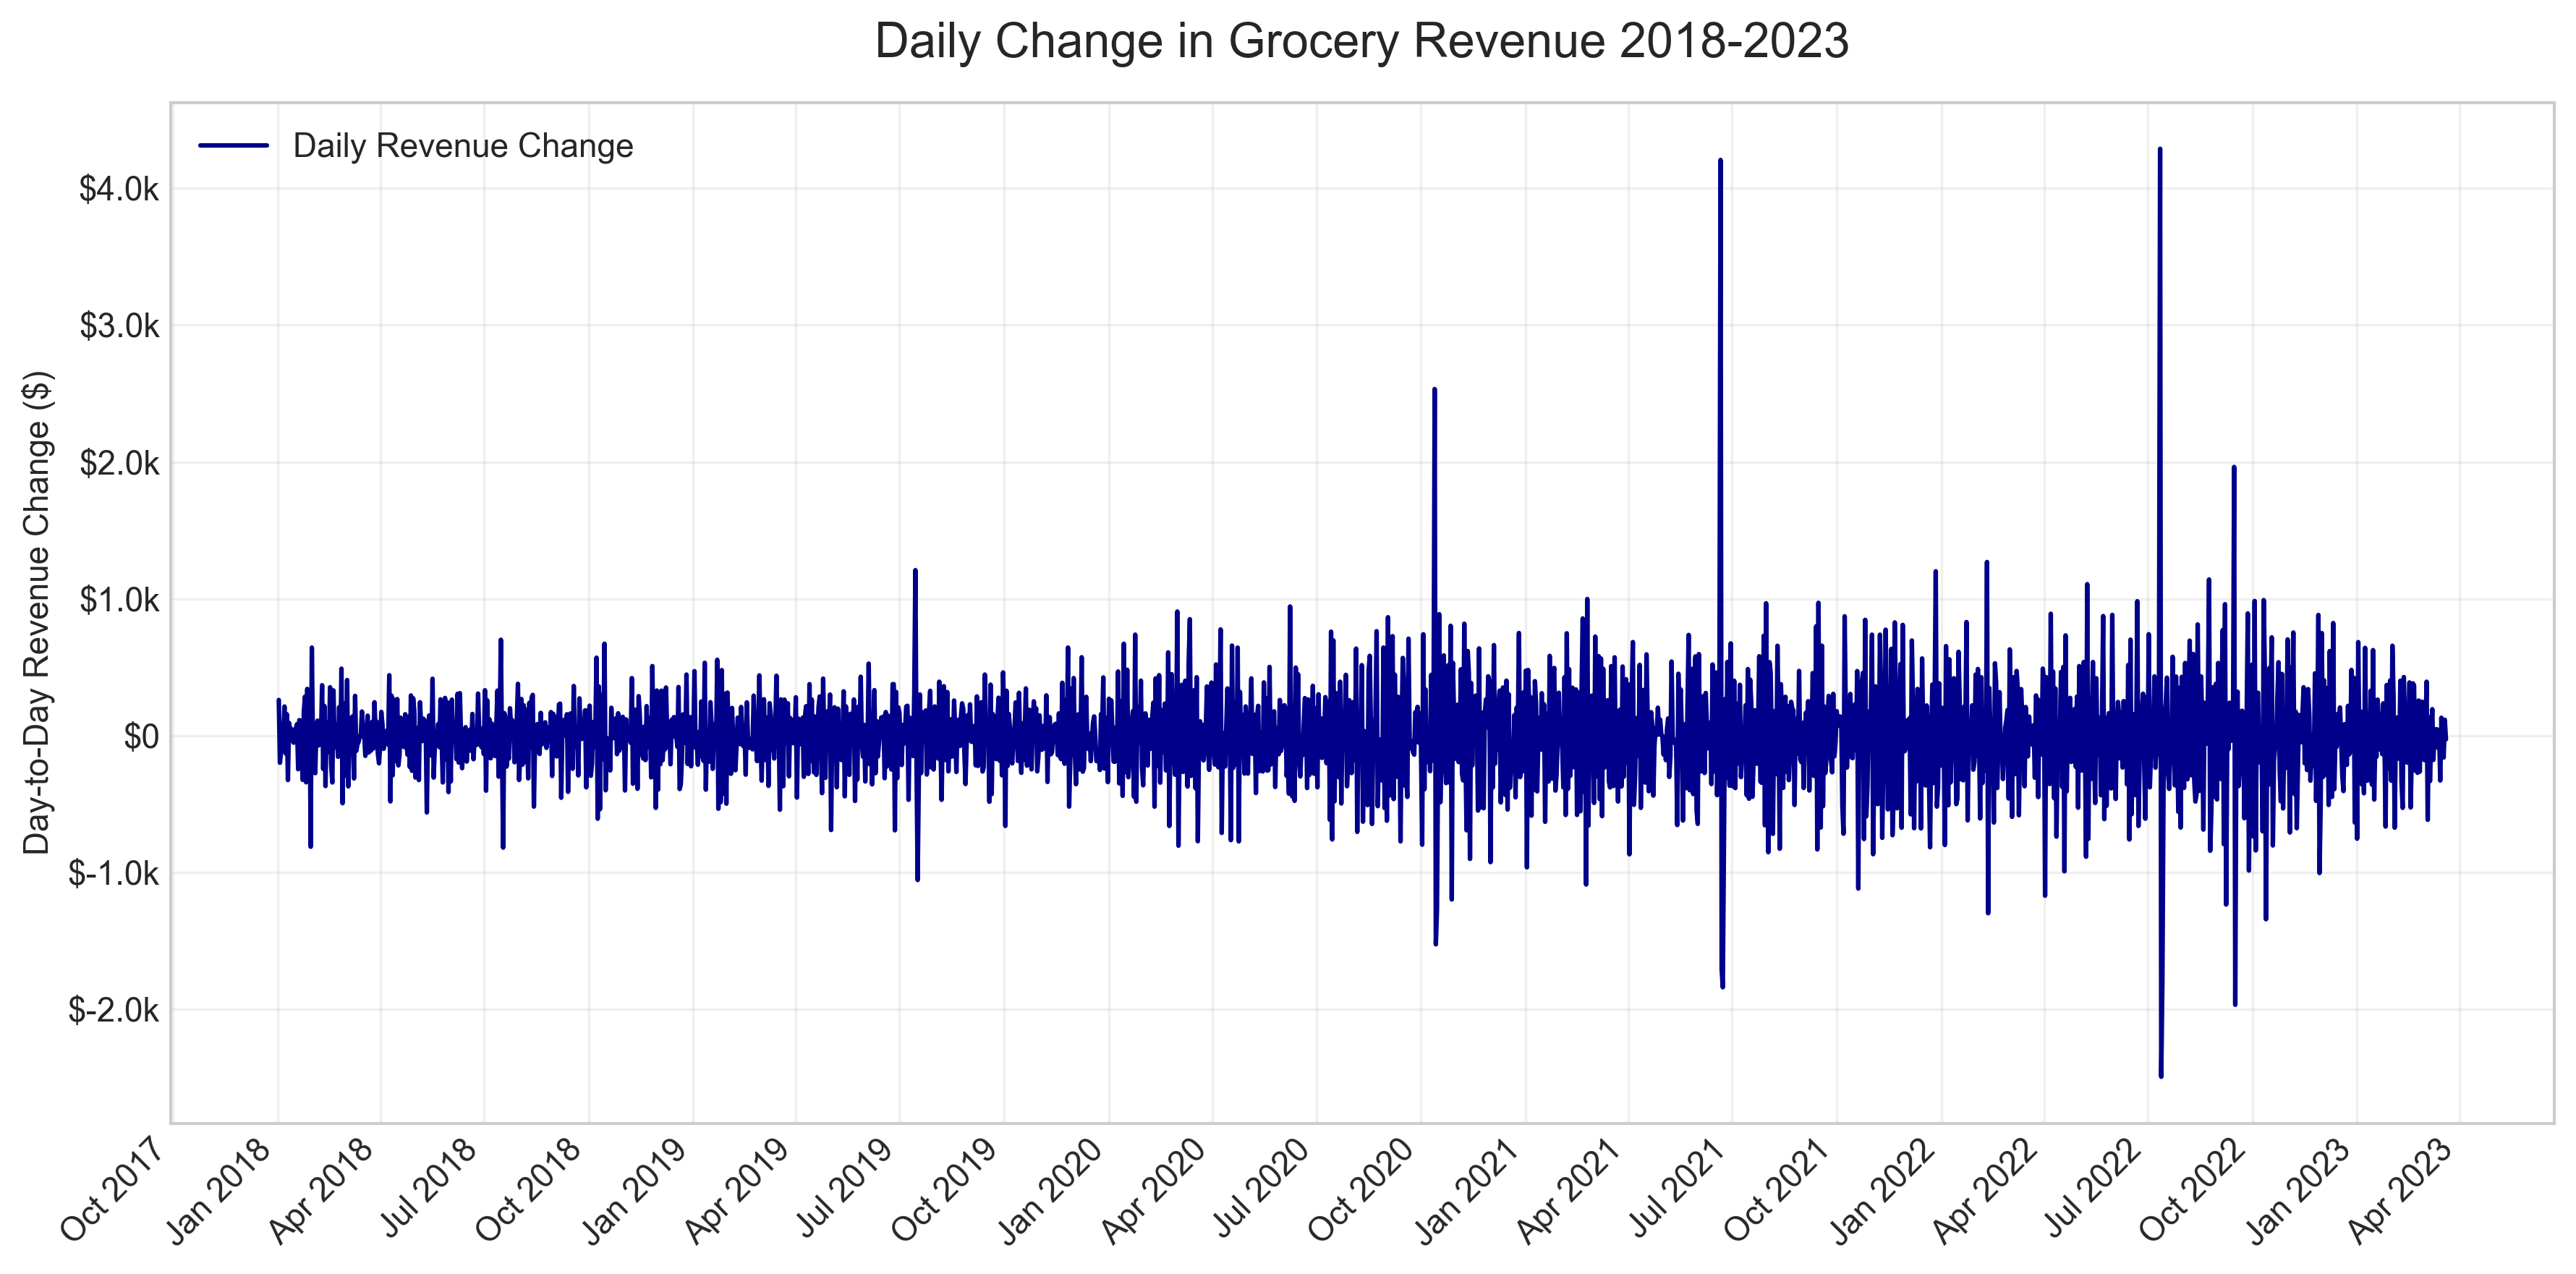

In [17]:
# Make sure the index is datetime
combined_grocery_df.index = pd.to_datetime(combined_grocery_df.index)

# Calculate the first-order difference of revenue
combined_grocery_df['Revenue_Diff'] = combined_grocery_df['Revenue'].diff()

# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if abs(x) >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot the first-order difference
ax.plot(combined_grocery_df.index[1:], combined_grocery_df['Revenue_Diff'].iloc[1:], 
        color='darkblue', alpha=1, linewidth=1.5, label='Daily Revenue Change')


# Add labels and title
ax.set_title('Daily Change in Grocery Revenue 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Day-to-Day Revenue Change ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) test

In [18]:
ADF_df = combined_grocery_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [19]:
### Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

### SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value SMA30: {adf_result[1]}')


p-value Revenue: 0.5595820038273827
p-value SMA7: 0.6680244493141386
p-value SMA30: 0.6461628454627977
p-value SMA30: 1.1911511146944316e-24


# Seasonality in Temperature

In [20]:
weather = pd.read_csv("./data/weather_data.csv")
print(weather.head())

   Unnamed: 0 st_abb  st_code      date stability     ppt    tmax    tmin  \
0           1     AL        1  20170101    stable  25.626  13.849   4.712   
1           2     AL        1  20170102    stable  40.827  17.970  12.968   
2           3     AL        1  20170103    stable  54.893  19.500  13.828   
3           4     AL        1  20170104    stable   0.048  19.158   8.744   
4           5     AL        1  20170105    stable   0.002  11.202  -0.147   

     tavg  dday_a0C  ...  dday_a25C  dday_a29C  dday_a30C  dday_a31C  \
0   9.280     9.280  ...      0.000        0.0        0.0        0.0   
1  15.469    15.469  ...      0.000        0.0        0.0        0.0   
2  16.664    16.665  ...      0.001        0.0        0.0        0.0   
3  13.951    13.951  ...      0.000        0.0        0.0        0.0   
4   5.527     5.714  ...      0.000        0.0        0.0        0.0   

   dday_a32C  dday_a33C  dday_a34C  dday_b15C  dday_b18C  dday_b21C  
0        0.0        0.0        0.0

In [21]:
weather['date'] = pd.to_datetime(weather['date'], format='%Y%m%d')

C:\Users\Moritz\AppData\Local\Temp\ipykernel_22972\3034634662.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


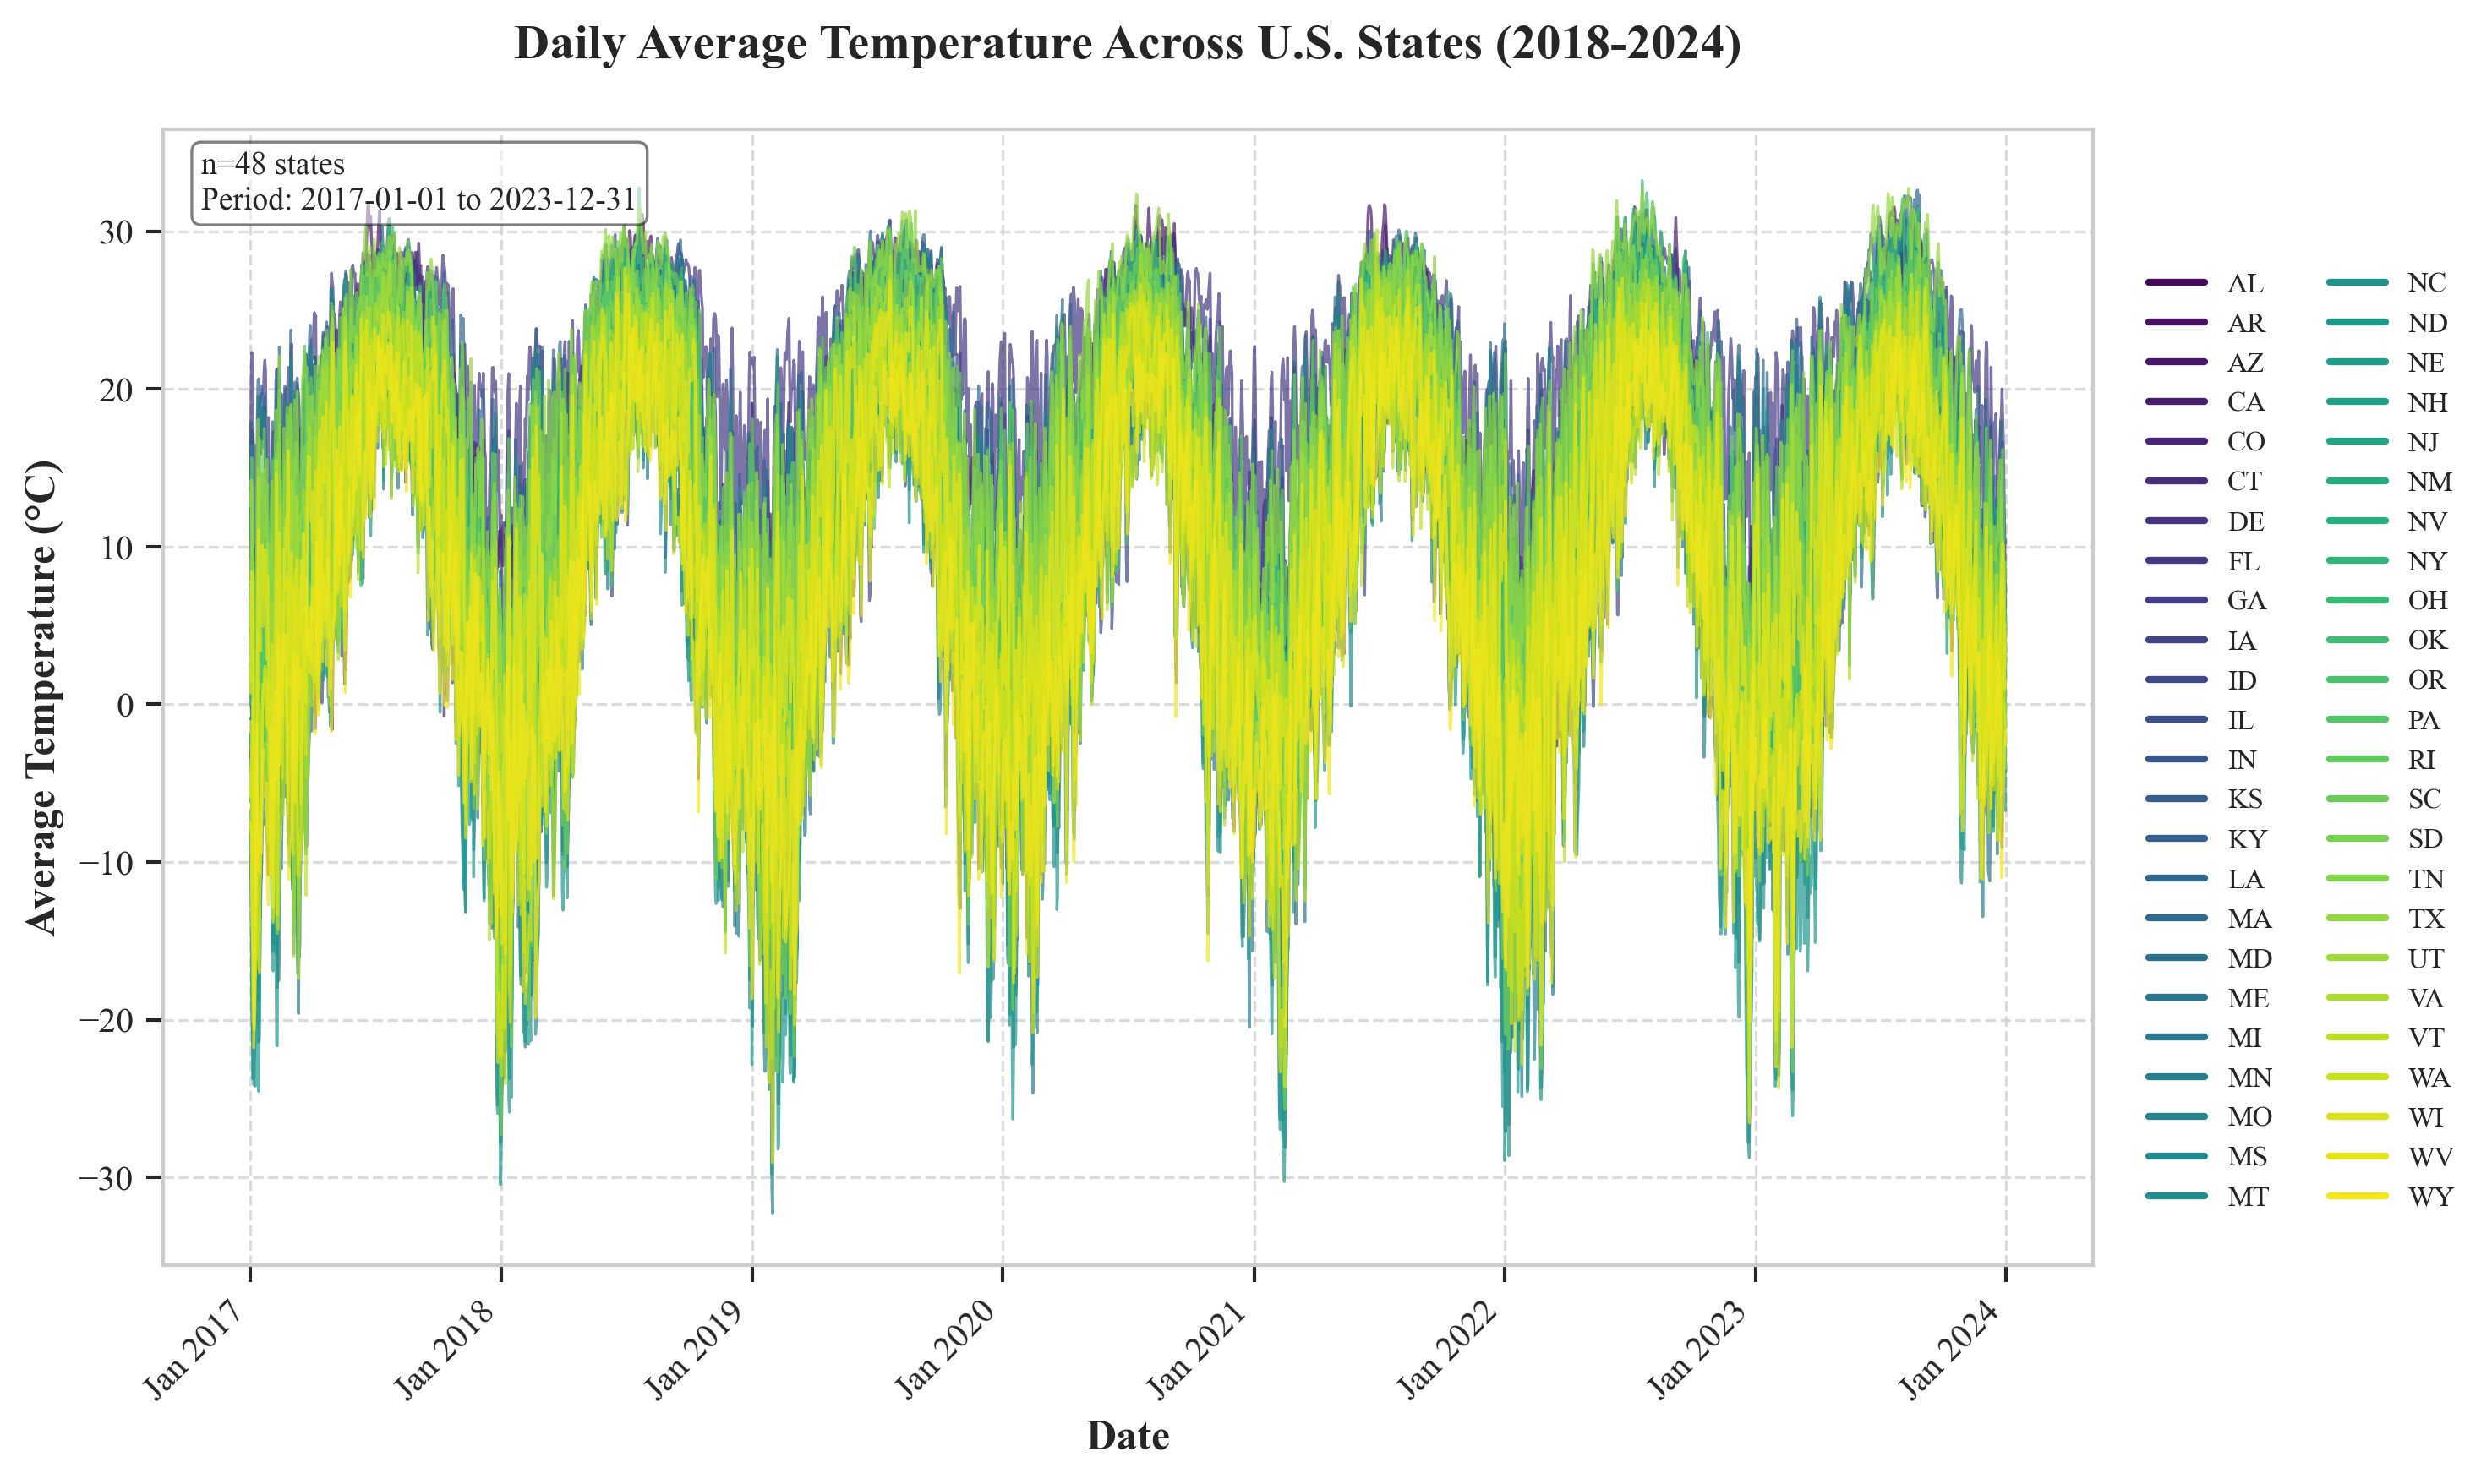

In [28]:
from matplotlib.gridspec import GridSpec
from matplotlib.dates import DateFormatter

#plt.style.use('seaborn-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Create a figure with proper sizing for academic publication (typically 7-8 inches wide)
fig = plt.figure(figsize=(10, 6), dpi=300)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])

# Get a list of unique states
states = weather['st_abb'].unique()

# Calculate the mean temperature for each state on each date
state_temp_by_date = weather.pivot_table(index='date', columns='st_abb', values='tavg', aggfunc='mean')

# Use a colorblind-friendly palette with enough distinct colors
palette = sns.color_palette("viridis", len(states))

# Plot each state's temperature over time
for i, state in enumerate(states):
    ax.plot(state_temp_by_date.index, state_temp_by_date[state], 
            color=palette[i], linewidth=0.8, alpha=0.7)

# Create a more sophisticated legend using a separate axes
# This helps when you have many states
legend_ax = fig.add_axes([0.85, 0.15, 0.13, 0.7])  # [left, bottom, width, height]
legend_ax.axis('off')

# Add state names to legend in alphabetical order with colored markers
for i, state in enumerate(sorted(states)):
    legend_ax.plot([0], [0], color=palette[list(states).index(state)], linewidth=2, label=state)

legend_ax.legend(loc='center', frameon=False, fontsize=8, ncol=2)

# Format the axes for academic standards
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
ax.tick_params(axis='both', labelsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add grid lines for readability
ax.grid(True, linestyle='--', alpha=0.7)

# Add a descriptive title
ax.set_title('Daily Average Temperature Across U.S. States (2018-2024)', 
            fontsize=14, fontweight='bold', pad=20)

# Add a text box with statistical information
text_str = f'n={len(states)} states\nPeriod: {weather.date.min().strftime("%Y-%m-%d")} to {weather.date.max().strftime("%Y-%m-%d")}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(0.02, 0.98, text_str, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

# Add a secondary plot showing state-by-state average temperatures


"""ax2 = fig.add_axes([0.12, 0.12, 0.3, 0.25])
state_means = weather.groupby('st_abb')['tavg'].mean().sort_values()
sns.barplot(x=state_means.index, y=state_means.values, ax=ax2, palette=palette)
ax2.set_title('Mean Temperature by State', fontsize=8)
ax2.tick_params(axis='x', rotation=90, labelsize=6)
ax2.tick_params(axis='y', labelsize=6)
ax2.set_xlabel('')
ax2.set_ylabel('Avg. Temp (°C)', fontsize=7)"""


# Adjust layout to ensure everything fits nicely
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save the figure in publication quality (adjust the DPI as needed)
plt.savefig('./Exports/us_state_temperatures.png', dpi=300, bbox_inches='tight')
#plt.savefig('us_state_temperatures.pdf', format='pdf', bbox_inches='tight')

plt.show()

C:\Users\Moritz\AppData\Local\Temp\ipykernel_18600\3323049146.py:4: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
C:\Users\Moritz\AppData\Local\Temp\ipykernel_18600\3323049146.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


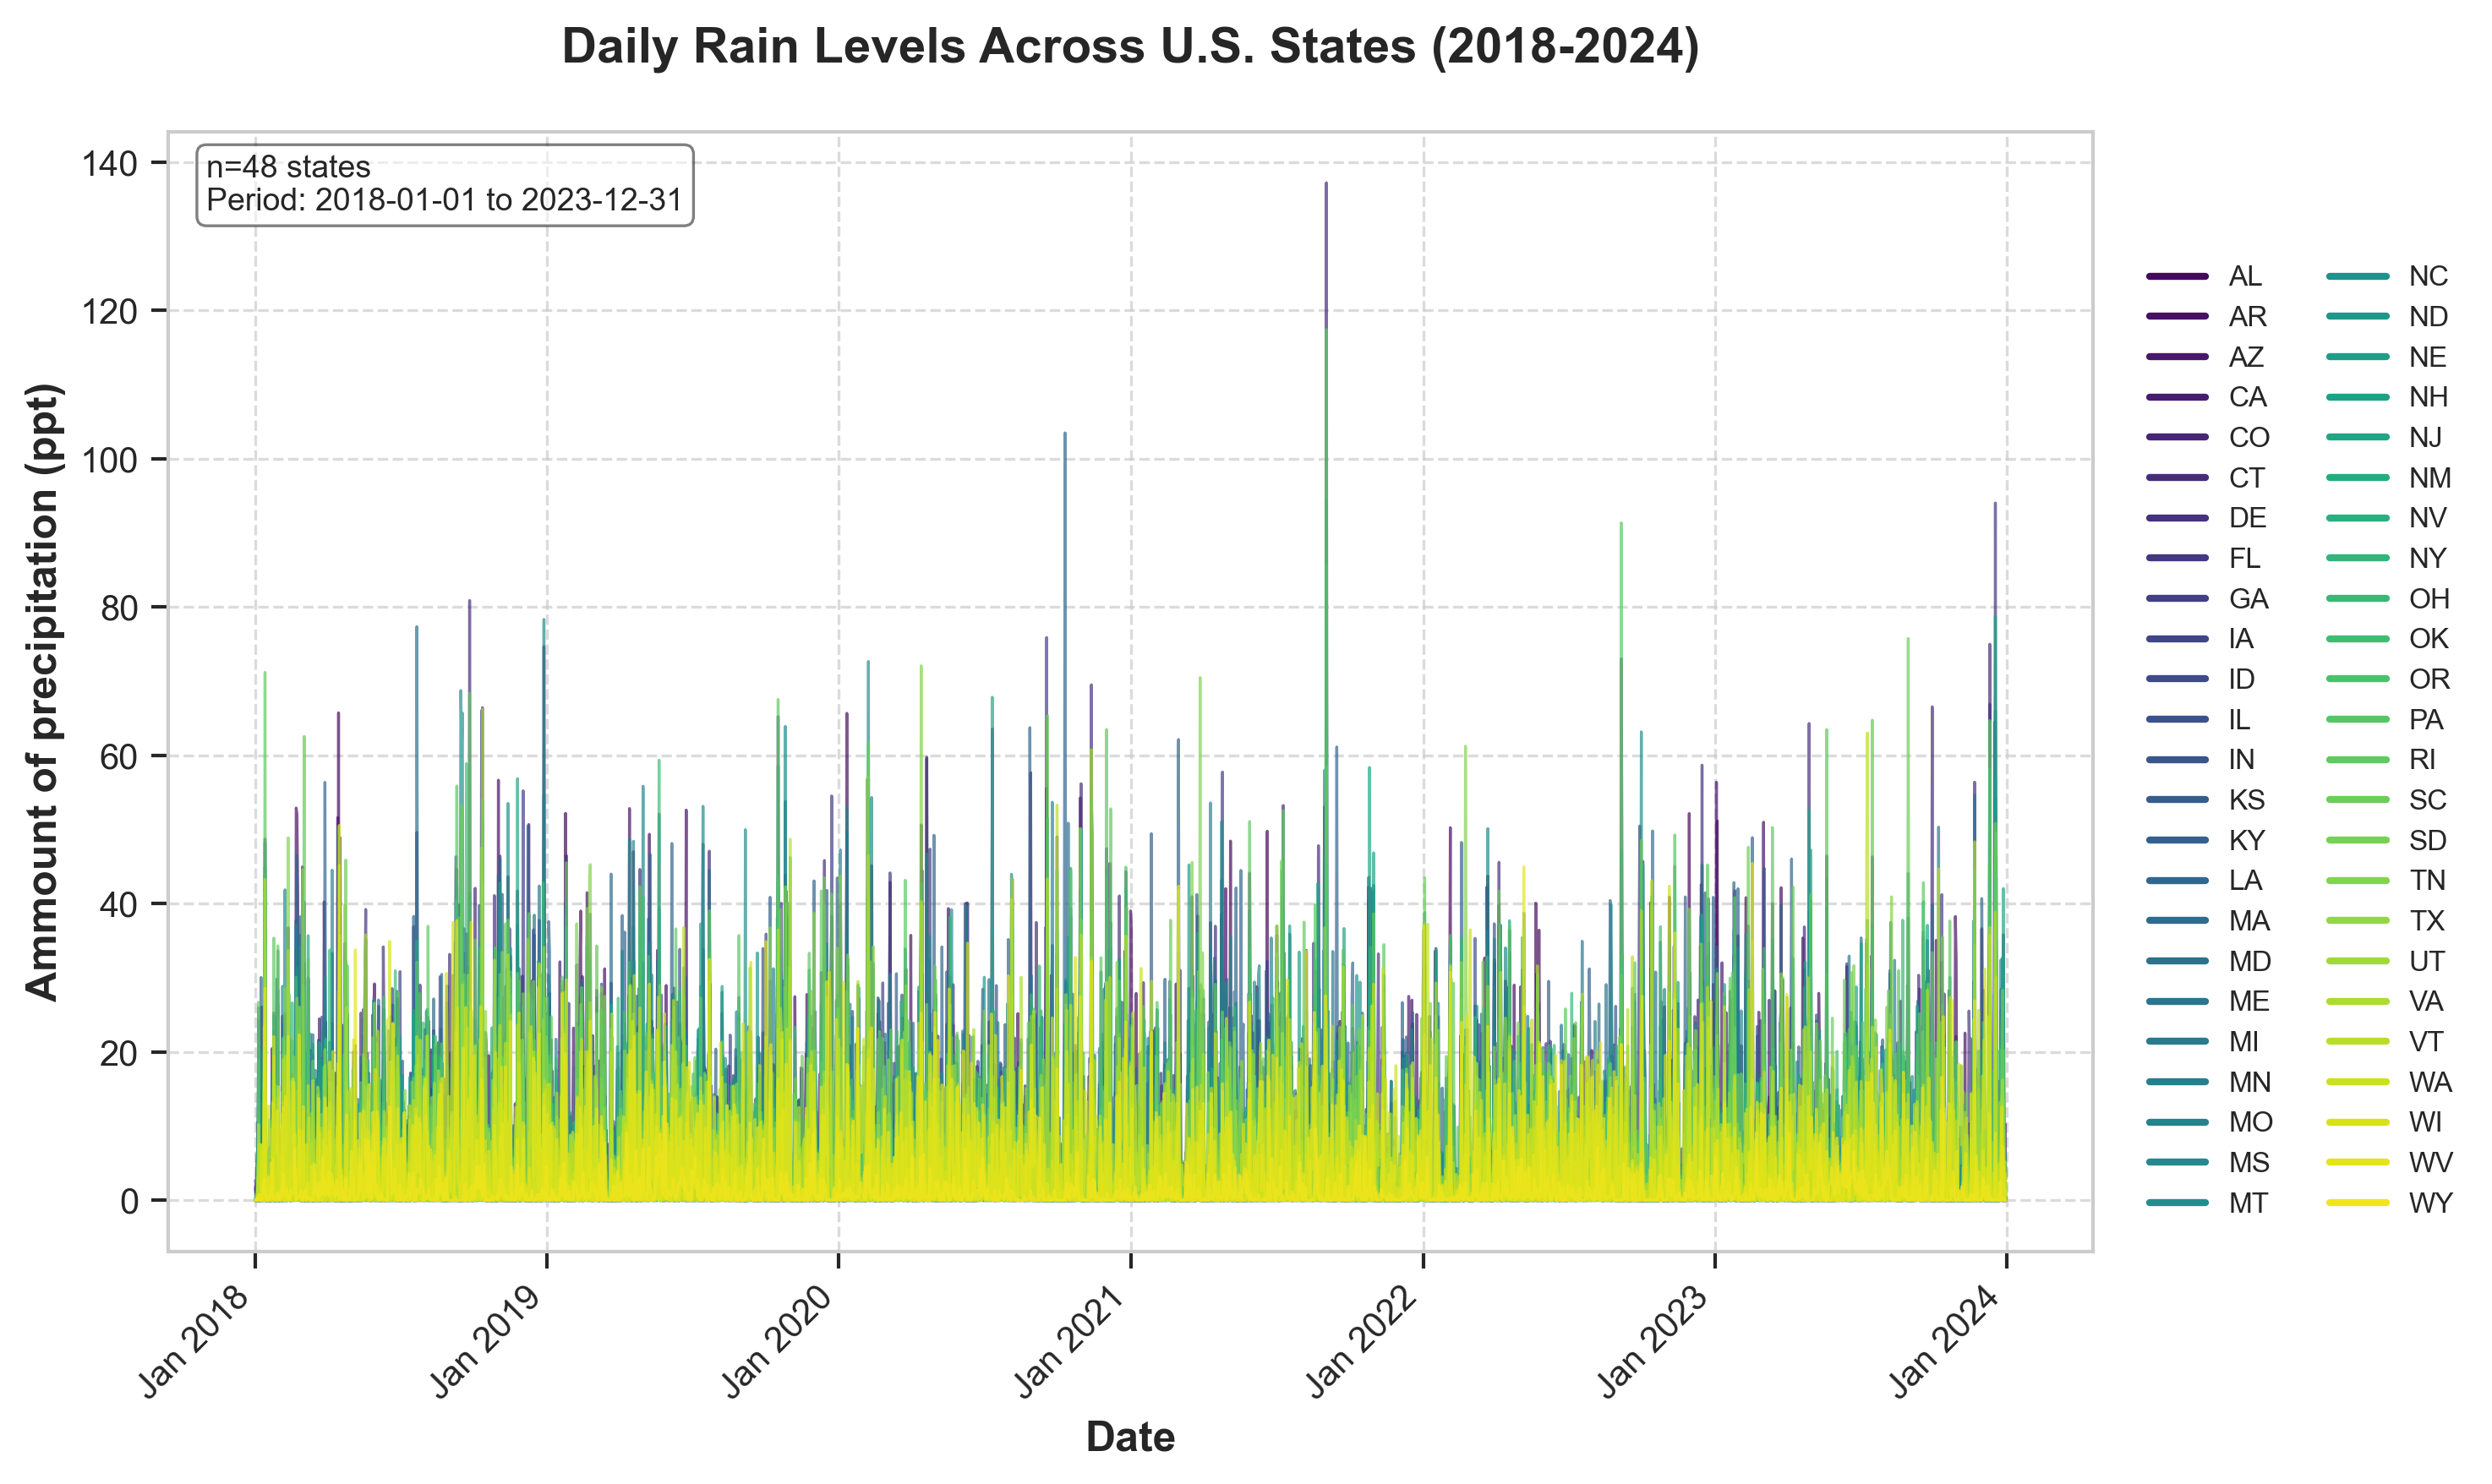

In [ ]:
from matplotlib.gridspec import GridSpec
from matplotlib.dates import DateFormatter

plt.style.use('seaborn-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Create a figure with proper sizing for academic publication (typically 7-8 inches wide)
fig = plt.figure(figsize=(10, 6), dpi=300)
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0])

# Get a list of unique states
states = weather['st_abb'].unique()

# Calculate the mean temperature for each state on each date
state_temp_by_date = weather.pivot_table(index='date', columns='st_abb', values='ppt', aggfunc='mean')

# Use a colorblind-friendly palette with enough distinct colors
palette = sns.color_palette("viridis", len(states))

# Plot each state's temperature over time
for i, state in enumerate(states):
    ax.plot(state_temp_by_date.index, state_temp_by_date[state], 
            color=palette[i], linewidth=0.8, alpha=0.7)

# Create a more sophisticated legend using a separate axes
# This helps when you have many states
legend_ax = fig.add_axes([0.85, 0.15, 0.13, 0.7])  # [left, bottom, width, height]
legend_ax.axis('off')

# Add state names to legend in alphabetical order with colored markers
for i, state in enumerate(sorted(states)):
    legend_ax.plot([0], [0], color=palette[list(states).index(state)], linewidth=2, label=state)

legend_ax.legend(loc='center', frameon=False, fontsize=8, ncol=2)

# Format the axes for academic standards
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Ammount of precipitation (ppt)', fontsize=12, fontweight='bold')
ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
ax.tick_params(axis='both', labelsize=10)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Add grid lines for readability
ax.grid(True, linestyle='--', alpha=0.7)

# Add a descriptive title
ax.set_title('Daily Rain Levels Across U.S. States (2018-2024)', 
            fontsize=14, fontweight='bold', pad=20)

# Add a text box with statistical information
text_str = f'n={len(states)} states\nPeriod: {weather.date.min().strftime("%Y-%m-%d")} to {weather.date.max().strftime("%Y-%m-%d")}'
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
ax.text(0.02, 0.98, text_str, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

# Add a secondary plot showing state-by-state average temperatures


"""ax2 = fig.add_axes([0.12, 0.12, 0.3, 0.25])
state_means = weather.groupby('st_abb')['tavg'].mean().sort_values()
sns.barplot(x=state_means.index, y=state_means.values, ax=ax2, palette=palette)
ax2.set_title('Mean Temperature by State', fontsize=8)
ax2.tick_params(axis='x', rotation=90, labelsize=6)
ax2.tick_params(axis='y', labelsize=6)
ax2.set_xlabel('')
ax2.set_ylabel('Avg. Temp (°C)', fontsize=7)"""


# Adjust layout to ensure everything fits nicely
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save the figure in publication quality (adjust the DPI as needed)
plt.savefig('./Exports/us_state_rain.png', dpi=300, bbox_inches='tight')
#plt.savefig('us_state_temperatures.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Single State (CA)

In [ ]:
fashion_CA = fashion_df[fashion_df['Shipping Address State'] == "CA"]
fashion_CA = fashion_CA[["Order Date", "Revenue"]]
grocery_CA = grocery_df[grocery_df['Shipping Address State'] == "CA"]
grocery_CA = grocery_CA[["Order Date", "Revenue"]]


### Visual Analysis

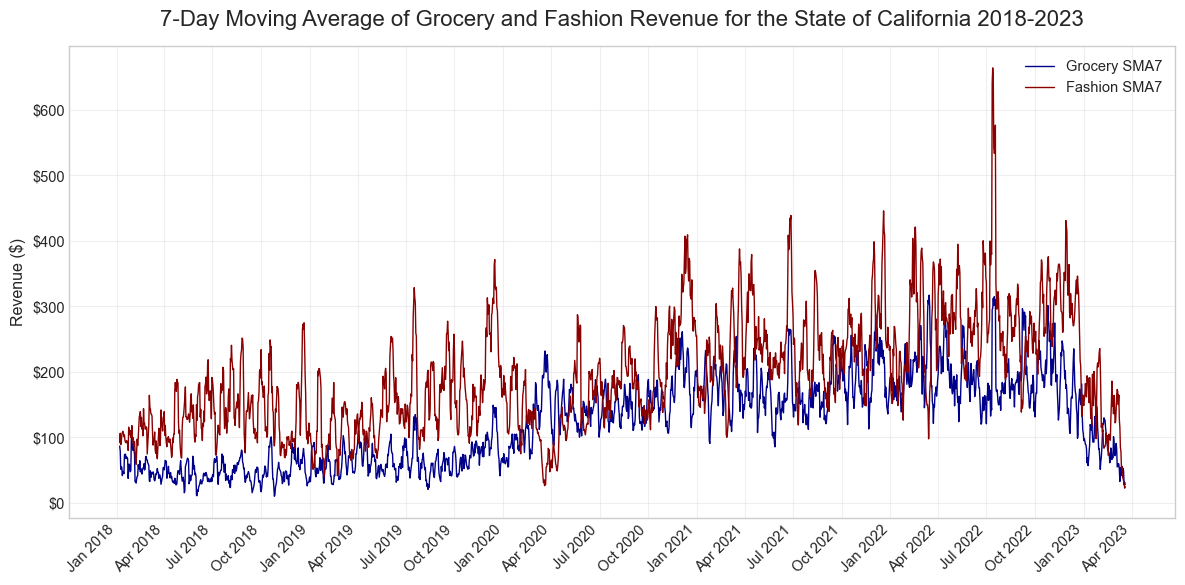

In [ ]:
# Make sure the index is datetime

combined_grocery_df = grocery_CA.copy()
combined_fashion_df = fashion_CA.copy()

combined_grocery_df.index = pd.to_datetime(grocery_CA["Order Date"])
combined_fashion_df.index = pd.to_datetime(fashion_CA["Order Date"])


# Calculate the 7-day Simple Moving Average
combined_grocery_df['SMA7'] = combined_grocery_df['Revenue'].rolling(window=7).mean()
combined_fashion_df['SMA7'] = combined_fashion_df['Revenue'].rolling(window=7).mean()

# Calcualte SMA30 
combined_grocery_df['SMA30'] = combined_grocery_df['Revenue'].rolling(window=30).mean()
combined_fashion_df['SMA30'] = combined_fashion_df['Revenue'].rolling(window=30).mean()

# Calucalte firsto order difference
combined_fashion_df['Revenue_Diff'] = combined_fashion_df['Revenue'].diff()
combined_grocery_df['Revenue_Diff'] = combined_grocery_df['Revenue'].diff()


# Create a function to format y-axis as $X.XXk
def currency_formatter(x, pos):
    if x >= 1000:
        return f'${x/1000:.1f}k'
    else:
        return f'${x:.0f}'

# Set the style
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6)) 

# Plot only the 7-day SMA (not the daily revenue)
ax.plot(combined_grocery_df.index, combined_grocery_df['SMA7'], 
        color='darkblue', linewidth=1, alpha=1,label='Grocery SMA7')

ax.plot(combined_fashion_df.index, combined_fashion_df['SMA7'], 
        color='darkred', linewidth=1, alpha=1,label='Fashion SMA7')

# Add trend line for the SMA7 instead of daily revenue
"""x = np.arange(len(combined_grocery_df))
z = np.polyfit(x[6:], combined_grocery_df['SMA7'].dropna(), 1)  # Start from index 6 to skip NaN values
p = np.poly1d(z)
ax.plot(combined_grocery_df.index[6:], p(np.arange(len(combined_grocery_df)-6)), 
        "k--", linewidth=1.5, alpha=0.8, label=f'Trend Line (${z[0]:.2f}/day)')"""

# Add labels and title
ax.set_title('7-Day Moving Average of Grocery and Fashion Revenue for the State of California 2018-2023', fontsize=16, pad=15)
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='best')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## ADF Test

### Fashion

In [ ]:
ADF_df = combined_fashion_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [ ]:
### Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

### SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value First order difference: {adf_result[1]}')

p-value Revenue: 0.00023753670907228824
p-value SMA7: 0.006140366691819917
p-value SMA30: 0.017713466289914458
p-value First order difference: 5.8631717520802035e-28


### Grocery

In [ ]:
ADF_df = combined_grocery_df.iloc[29:,] # Adjust df because of null values resulting from SMA30

In [ ]:
### Revenue -> Stationary
adf_result = adfuller(ADF_df["Revenue"])

print(f'p-value Revenue: {adf_result[1]}')

### SMA7 -> Stationary
adf_result = adfuller(ADF_df["SMA7"])
print(f'p-value SMA7: {adf_result[1]}')

### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["SMA30"])
print(f'p-value SMA30: {adf_result[1]}')


### SMA30 -> Not Stationary
adf_result = adfuller(ADF_df["Revenue_Diff"])
print(f'p-value First order difference: {adf_result[1]}')

p-value Revenue: 0.186617638738016
p-value SMA7: 0.3325225814797031
p-value SMA30: 0.580312824020623
p-value First order difference: 6.410157256171121e-26


# Adjusting the trend for Temperature
Note: This part has been done in the 0_Data_Processing File to keep data processing operations in one central location. <br>
For further information please refer to Creating trend free temperature on a state level in the 0_Data_Processing File.

# LEGACY CODE (CAN BE REMOVED BEFORE SUBMISSION)

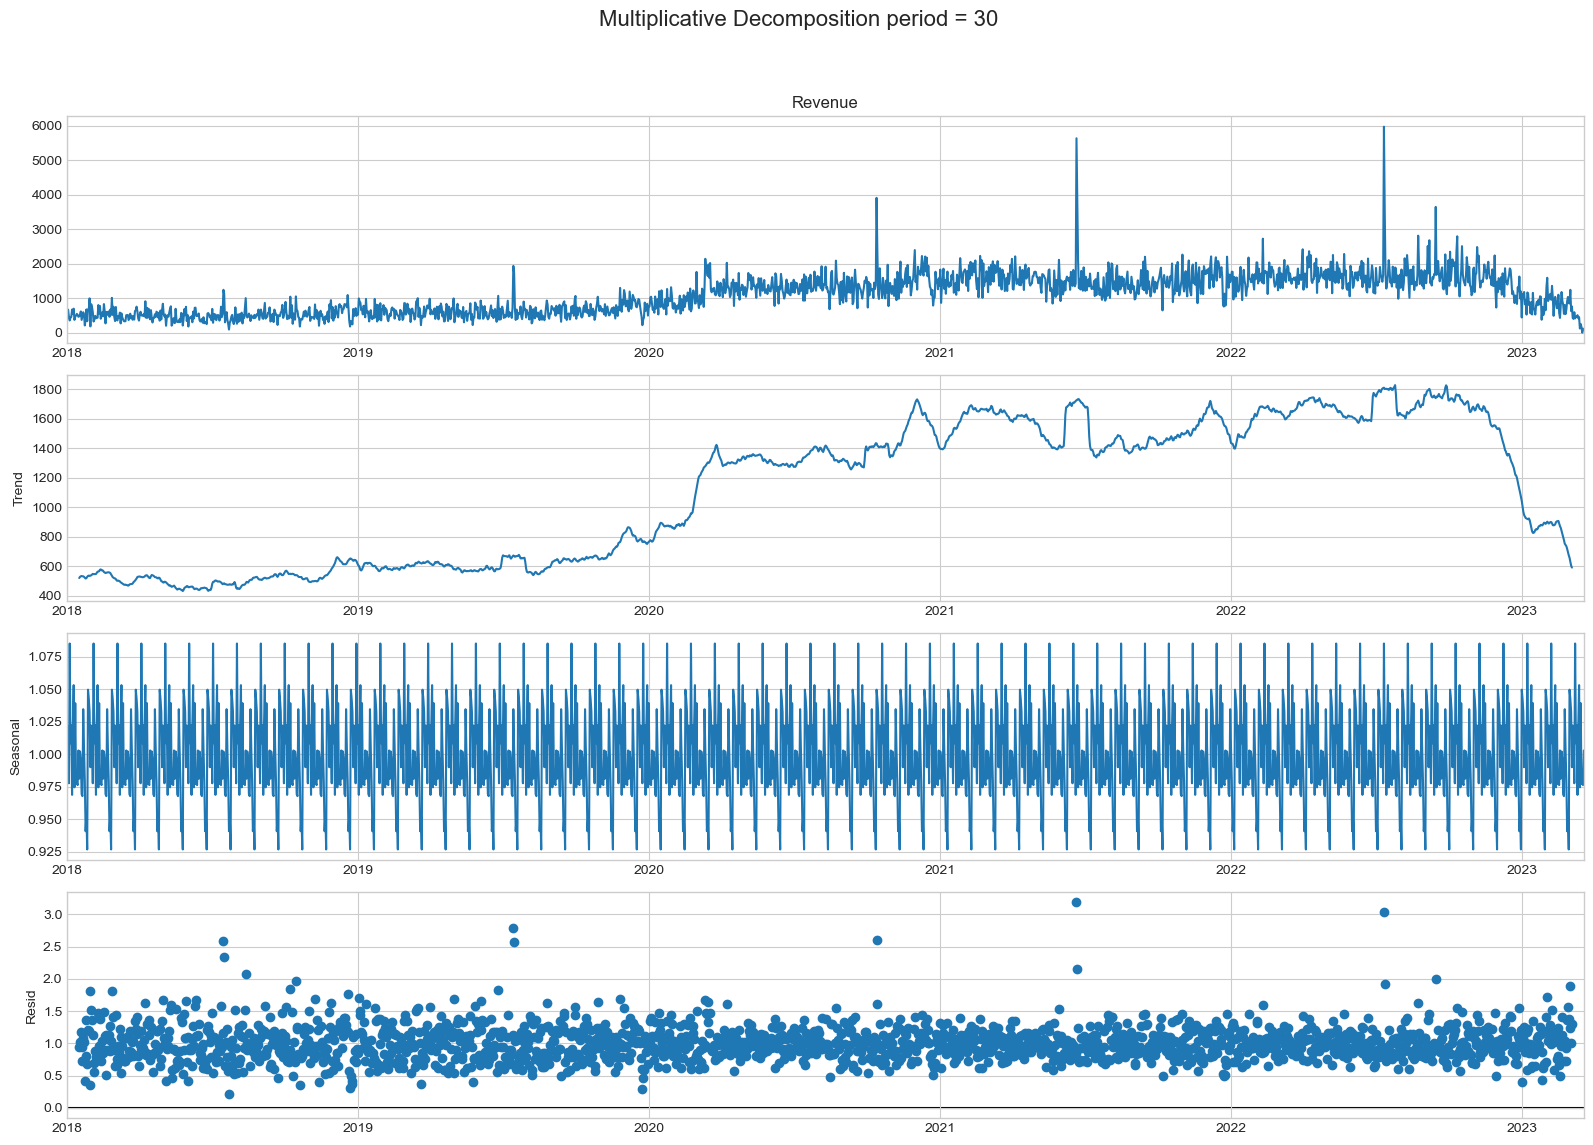

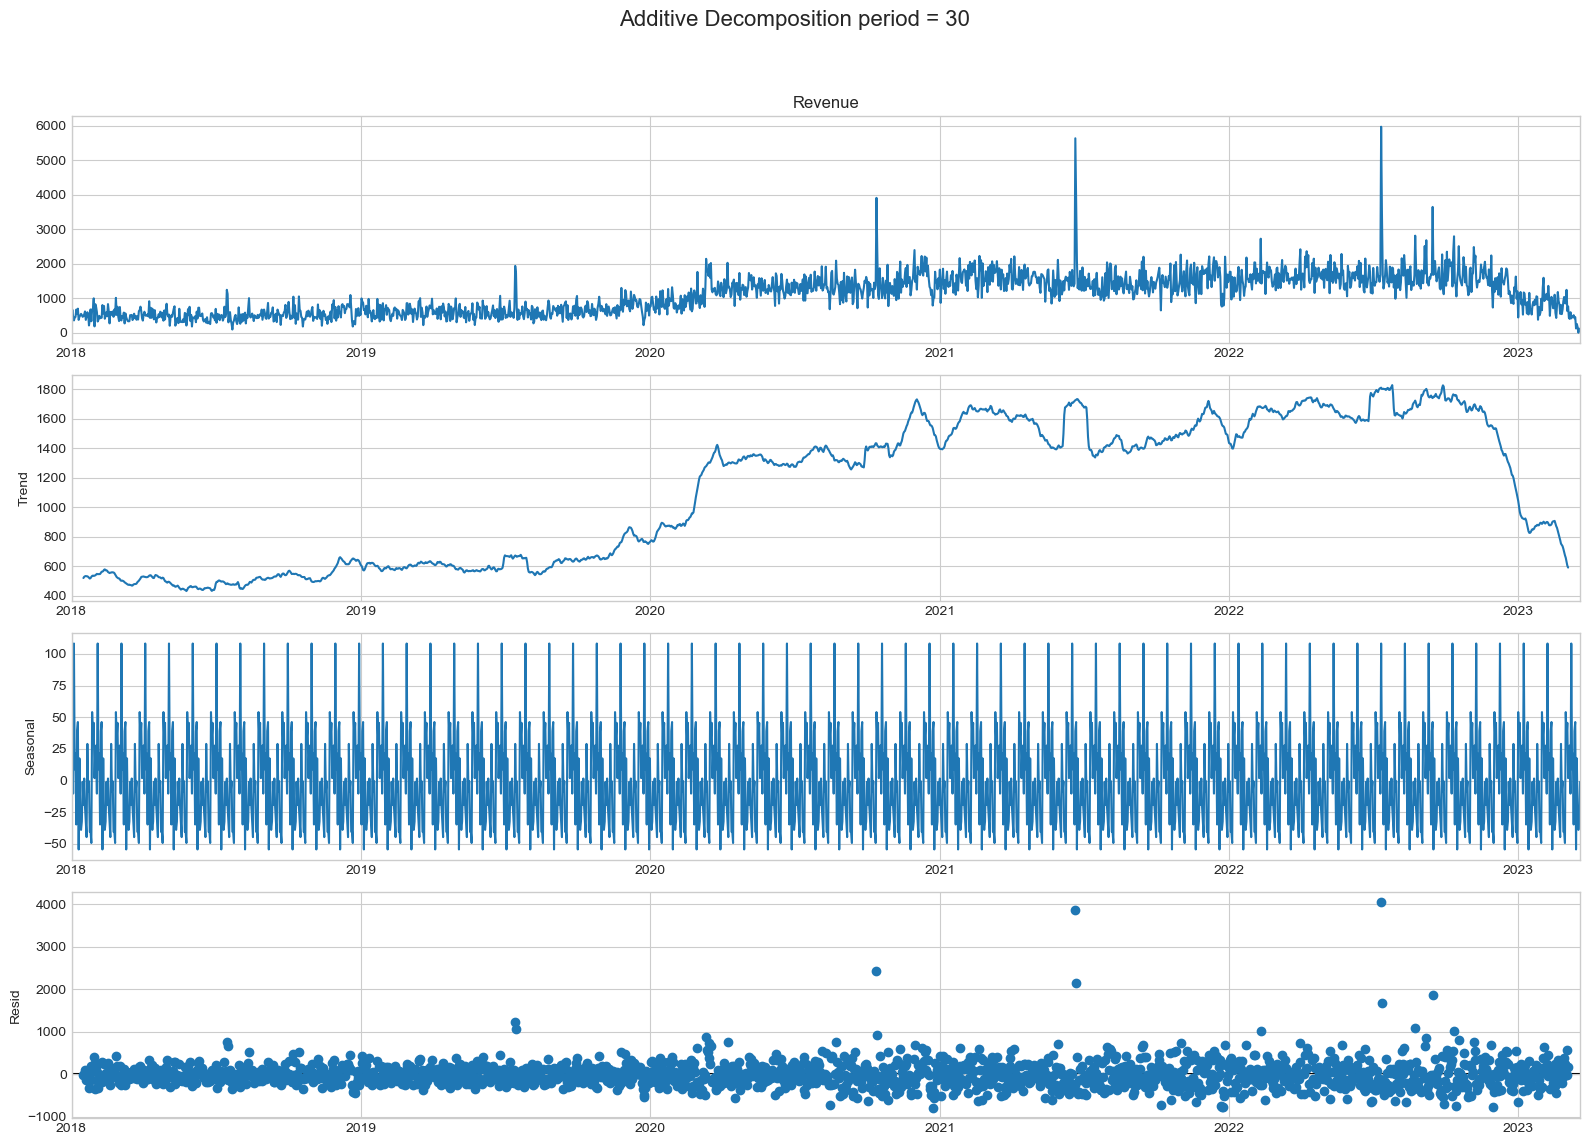

In [ ]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(combined_grocery_df["Revenue"], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(combined_grocery_df["Revenue"], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 30', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 30', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

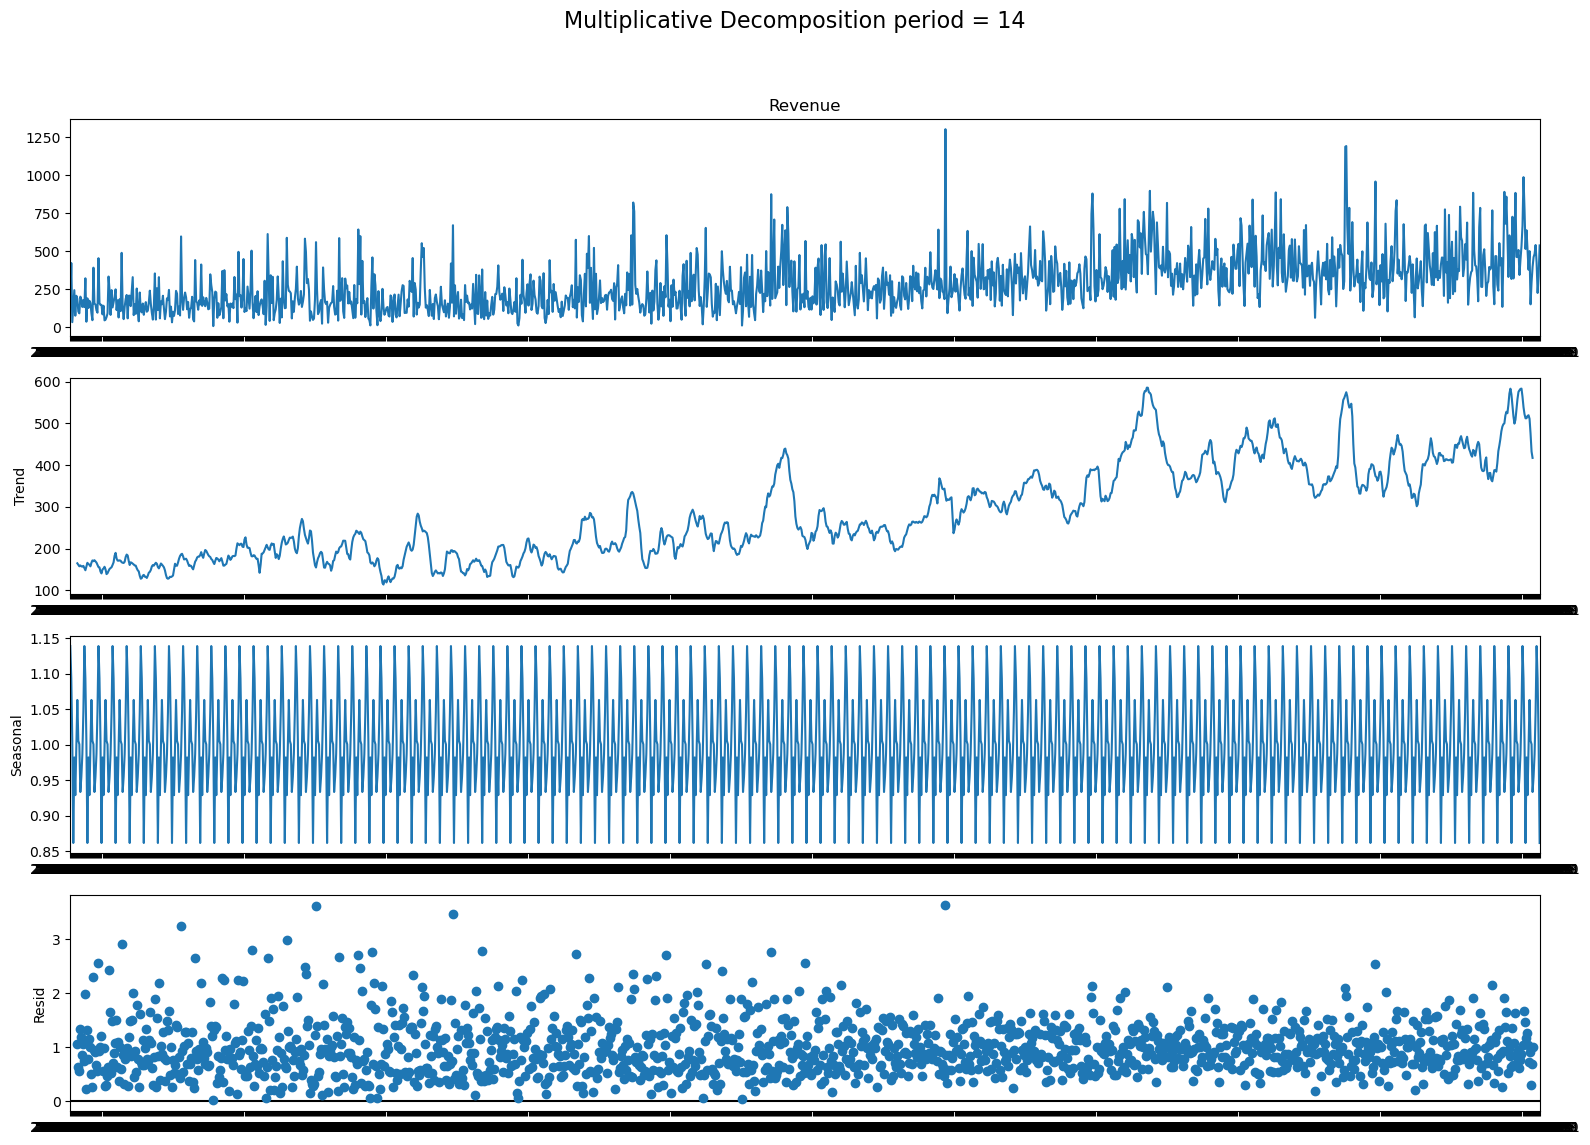

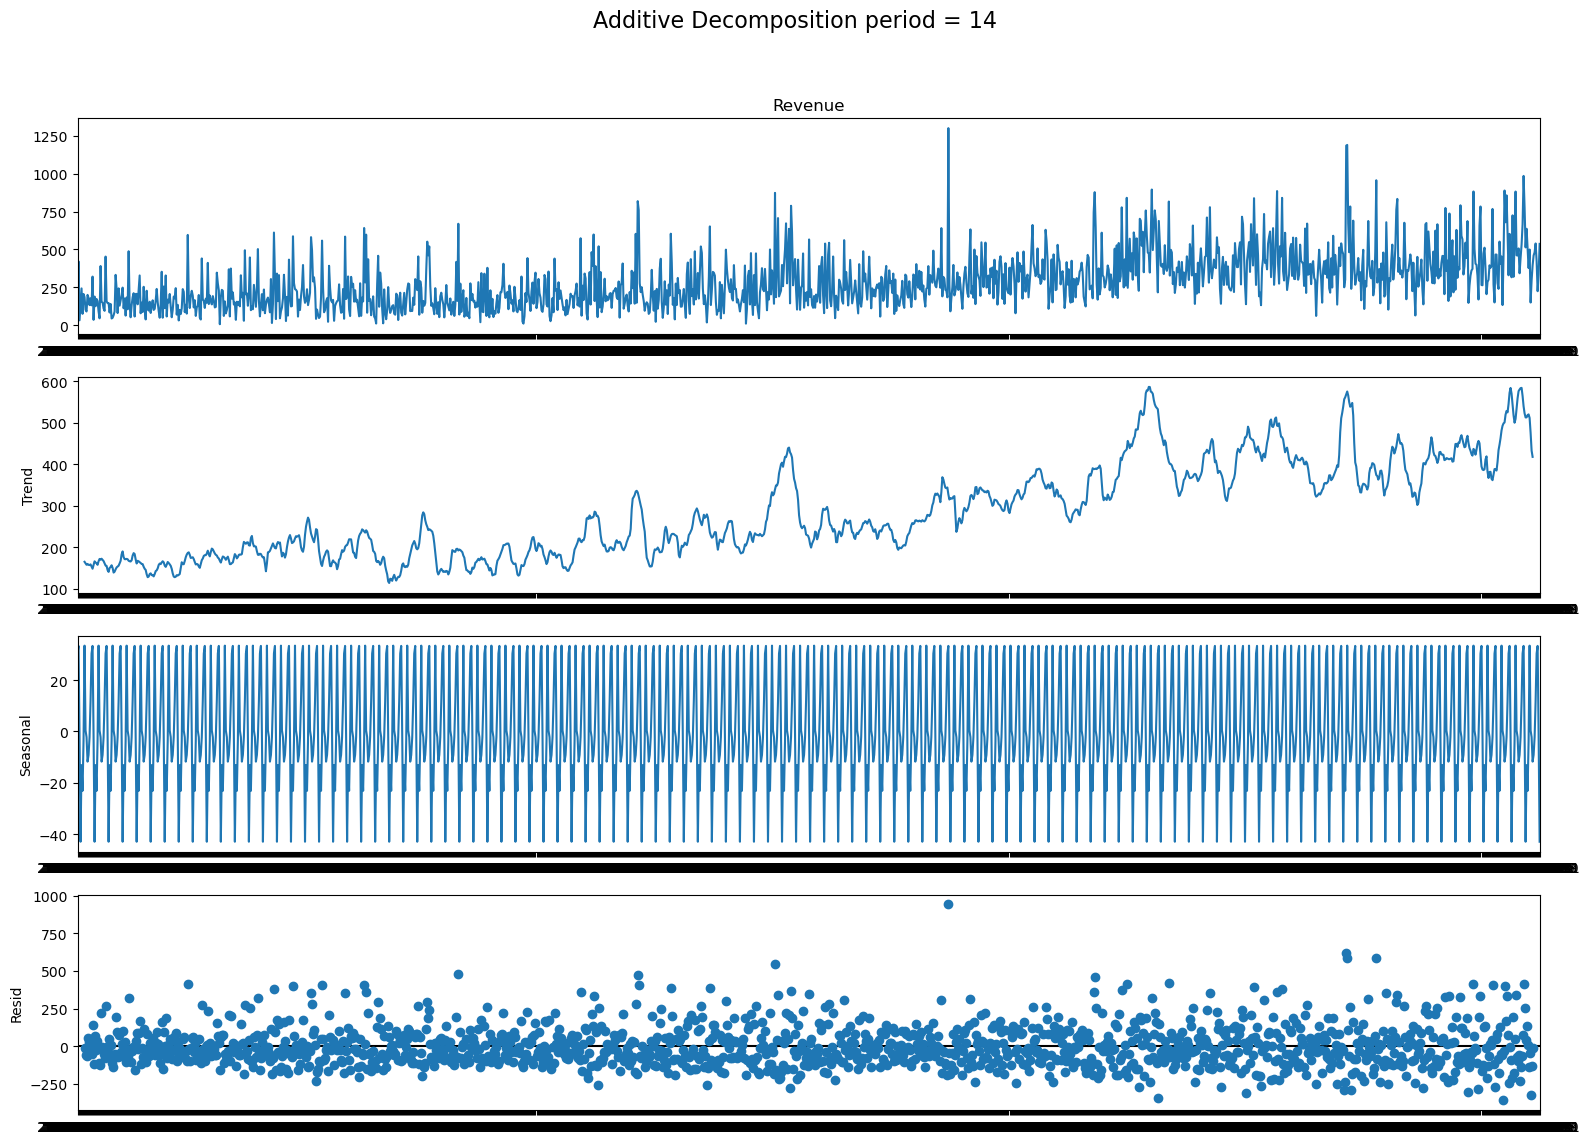

In [ ]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=14)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=14)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 14', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 14', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

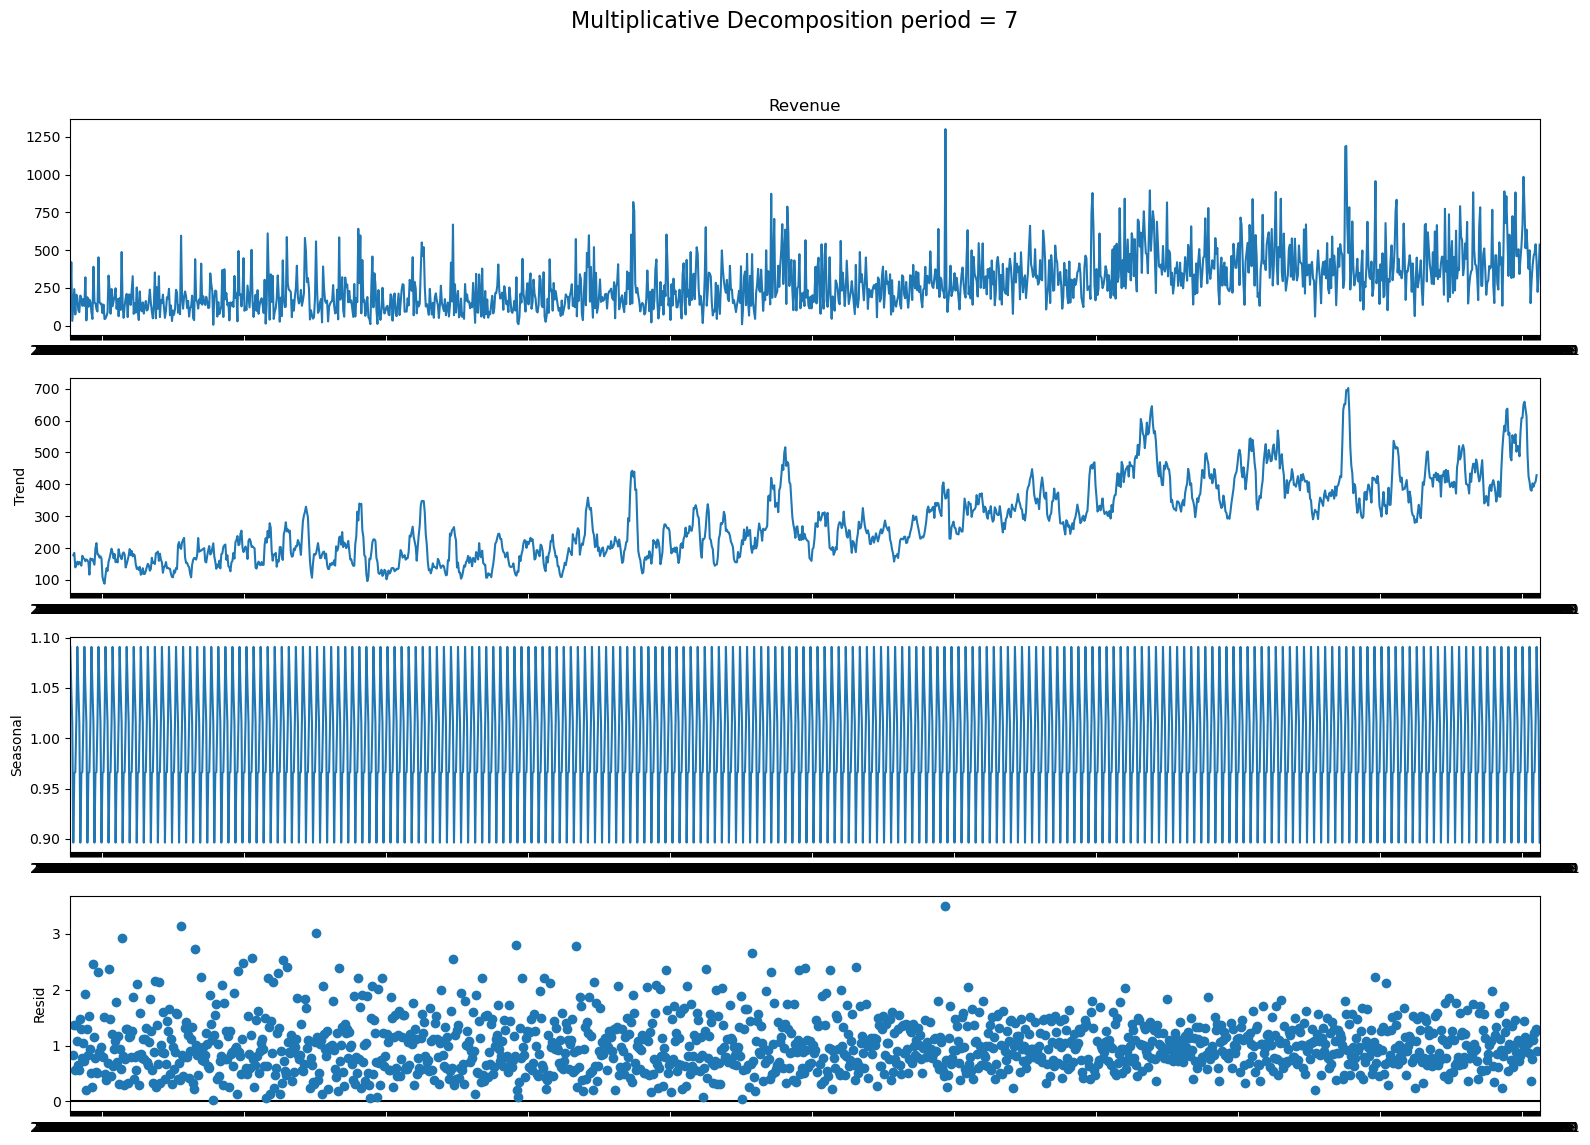

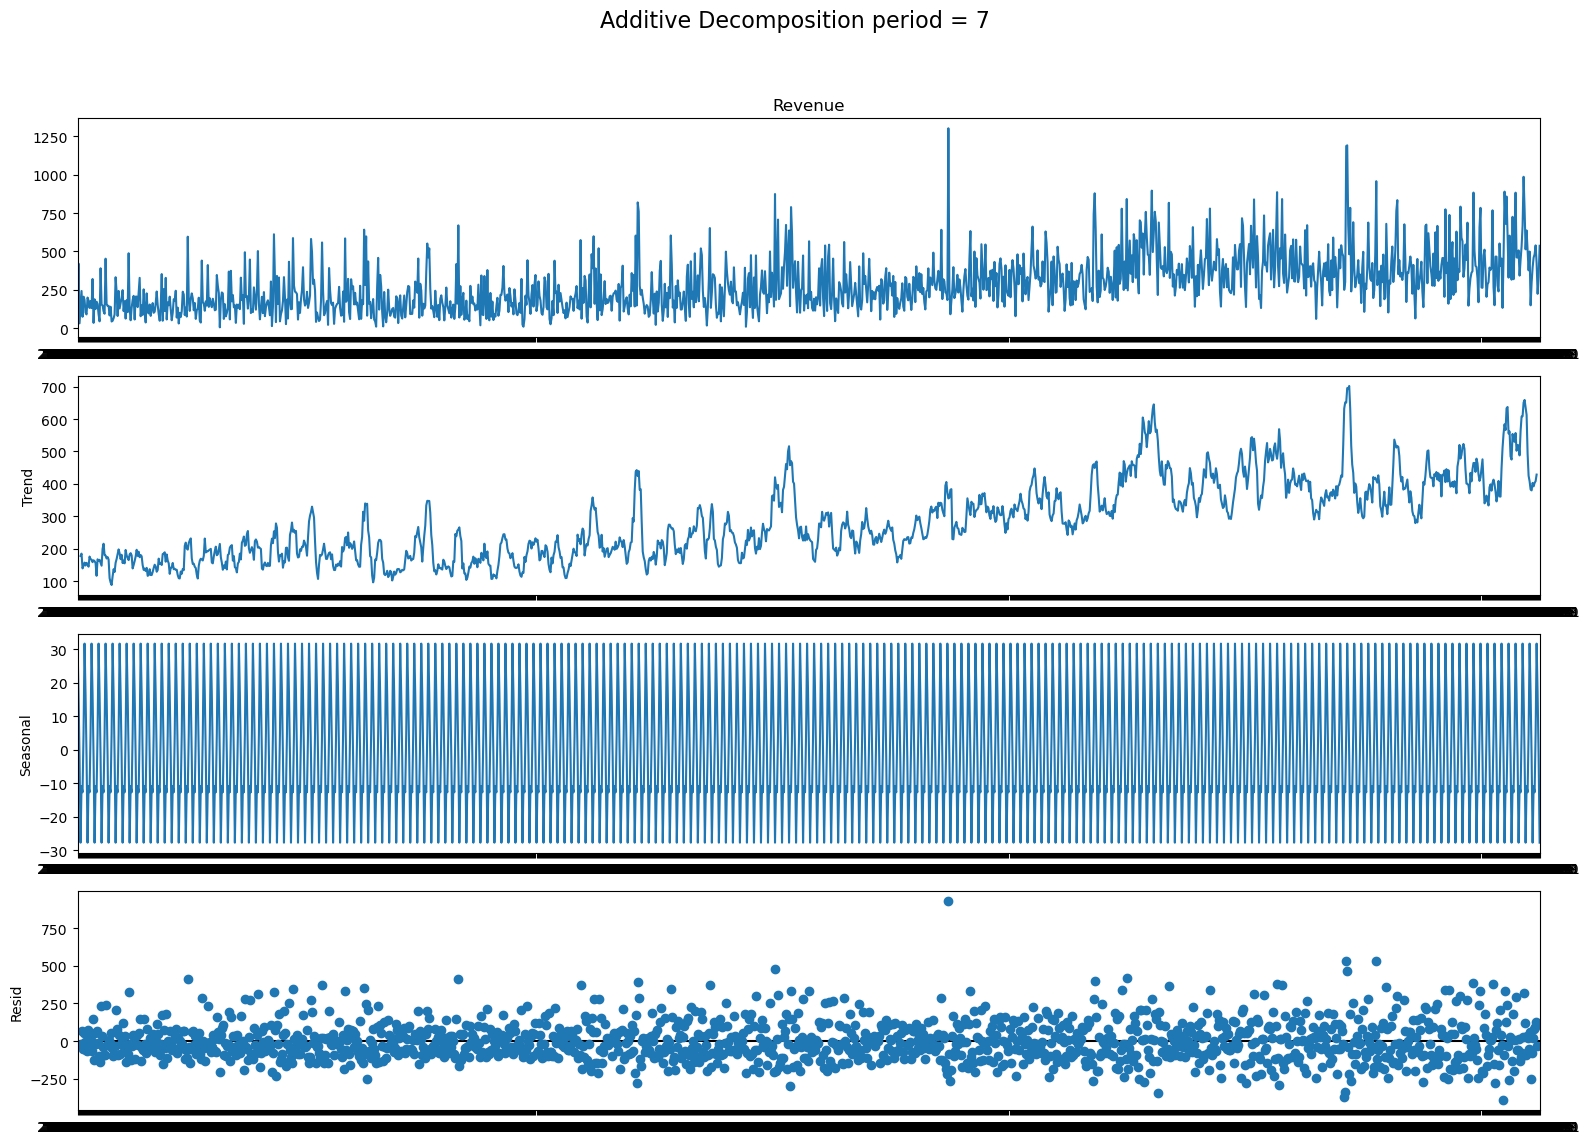

In [ ]:
# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=7)

# Additive Decomposition
additive_decomposition = seasonal_decompose(CA_only["Revenue"], model='additive', period=7)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition period = 7', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition period = 7', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Analysis of the Plots using Claude AI: 

#### Period = 30 days (Images 1 & 2):
Strong seasonal pattern with clear monthly cycles
Smoother trend component
Multiplicative model shows more consistent residuals compared to additive
Seasonal factors range from 0.85 to 1.2 (multiplicative) vs -40 to +60 (additive)


#### Period = 14 days (Images 3 & 4):
Bi-weekly patterns become visible
Trend line becomes slightly more volatile
Seasonal patterns are more frequent but still regular
Multiplicative decomposition maintains better residual stability


#### Period = 7 days (Images 5 & 6):
Weekly patterns are now visible
Trend component becomes more volatile
Seasonal patterns are very frequent
Residuals remain more stable in multiplicative model

Key Observations:

The multiplicative model appears superior across all periods because:

More consistent residual patterns regardless of the revenue level
Better handling of the increasing variance in the data
More stable seasonal factors


Period Selection:

Period = 30 shows the cleanest decomposition with:

Smoothest trend component
Clear seasonal patterns
Well-behaved residuals


Shorter periods (14, 7) introduce more noise in the trend component

### Detrending Revenue

Text(0.5, 1.0, 'Daily Revenue detrended by subtracting the trend component')

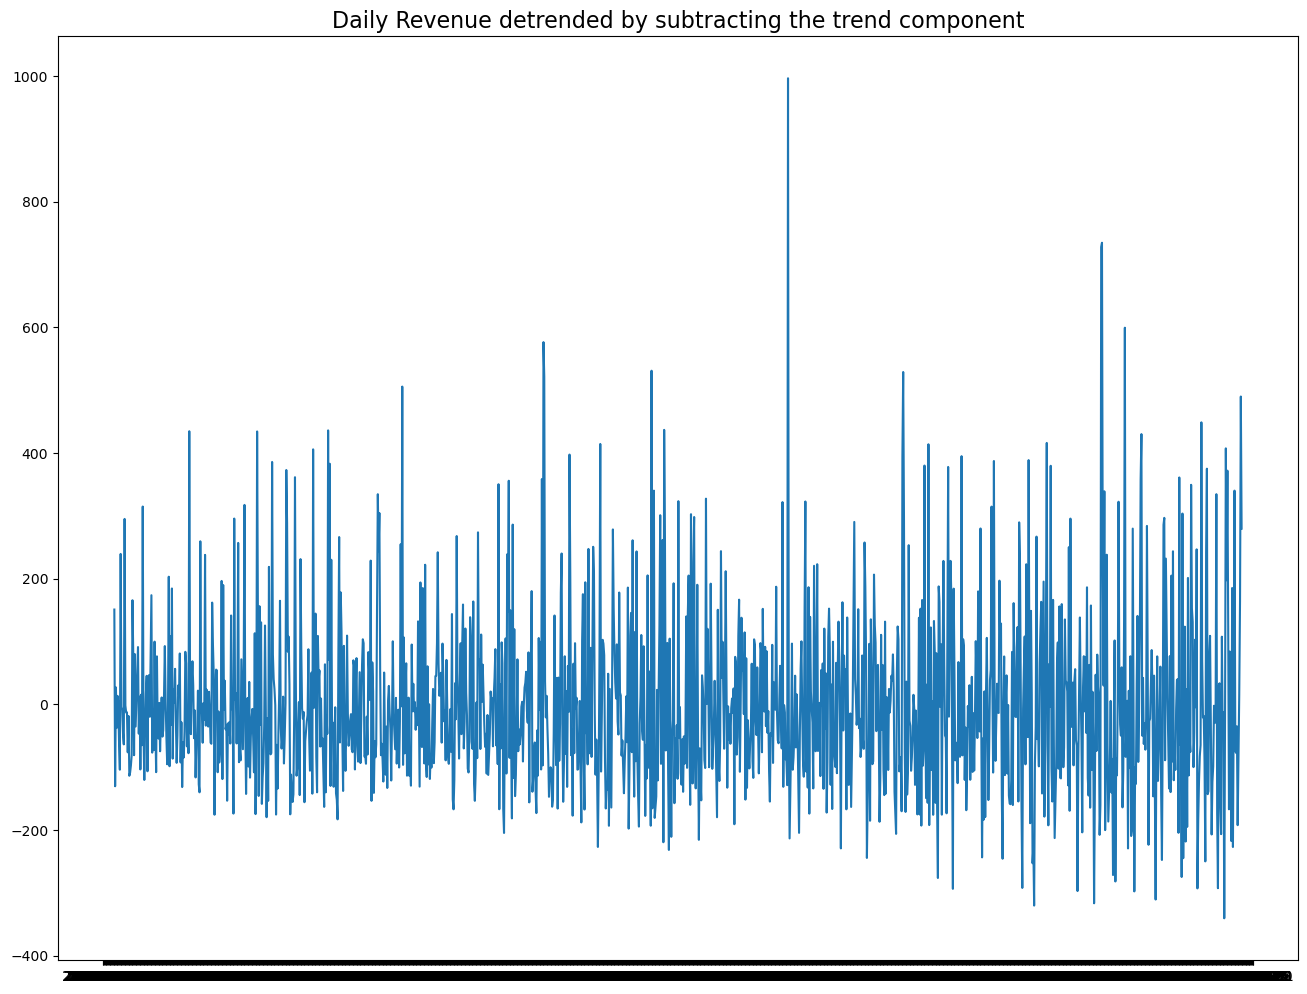

In [ ]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(CA_only["Revenue"], model='multiplicative', period=30)
detrended = CA_only["Revenue"].values - result_mul.trend
plt.plot(detrended)
plt.title('Daily Revenue detrended by subtracting the trend component', fontsize=16)

In [ ]:
detrended_filtered = detrended[29:]
detrended_filtered = detrended_filtered[:-15]

adf_result = adfuller(detrended_filtered)
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: -12.198278452576526
P-value: 1.240023078755318e-22


### Deseasonalizing Temperature

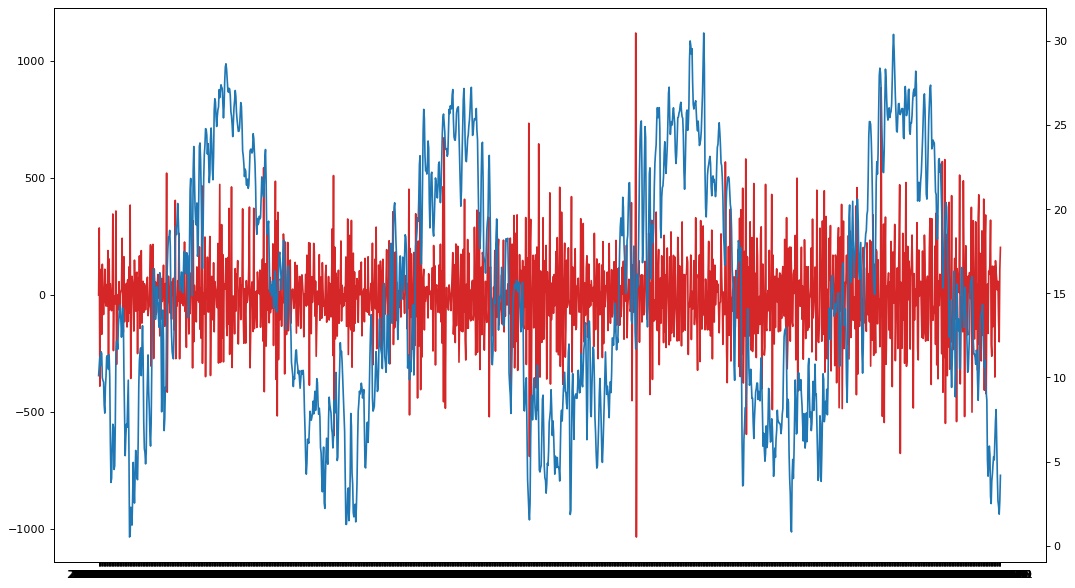

In [ ]:
CA_plot = CA_only.reset_index()

fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(CA_plot["Order Date"],
            CA_plot["first_oder_diff"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(CA_plot["Order Date"],
         CA_plot["tavg"],
         color="tab:blue")


In [ ]:
CA_only["Temp_No_Season"] = CA_only["tavg"] - CA_only["tavg"].shift(12*30)

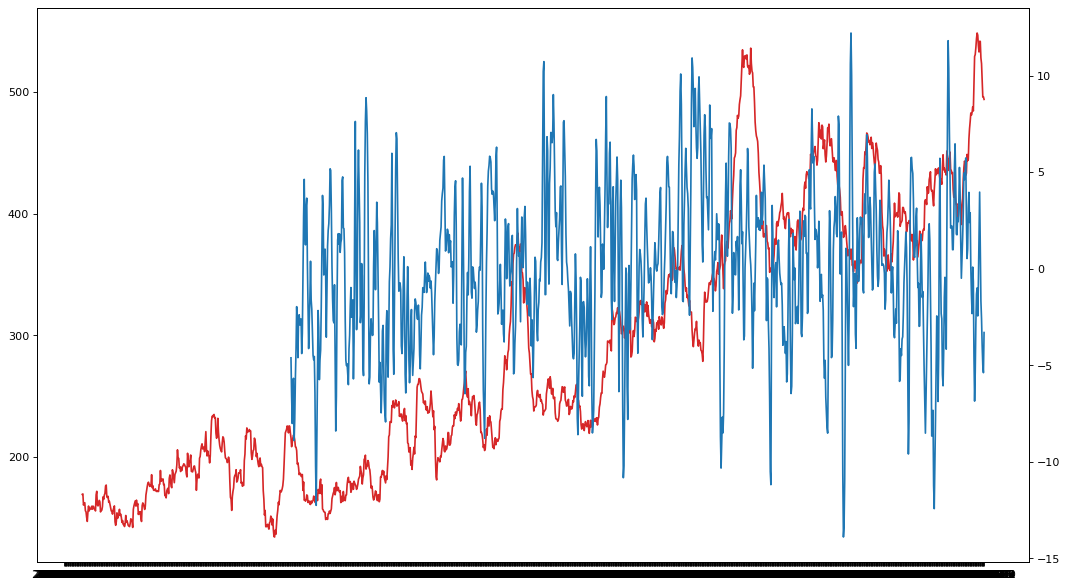

In [ ]:
CA_plot = CA_only.reset_index()

fig, ax1 = plt.subplots(1,1,figsize=(16,9), dpi= 80)


ax1.plot(CA_plot["Order Date"],
            CA_plot["Revenue_SMA30"],
            color="tab:red")

# Second line
ax2 = ax1.twinx()
ax2.plot(CA_plot["Order Date"],
         CA_plot["Temp_No_Season"],
         color="tab:blue")
